# EchoChain Drift Analysis

**How to read the metrics**

General
- Drift is reported in two modes: cumulative (seed→current hop) and local (previous hop→current hop). Cumulative shows total change since the seed; local shows the incremental change at each step.
- Higher drift means more change from the reference; higher fidelity means more preservation of the reference.

Surface-form
- Δ tokens (token_delta): Difference in token count. Positive values indicate expansion; negative indicate compression. Large magnitudes mean stronger stylistic change, not necessarily meaning change.
- Expansion ratio (token_expansion_ratio): Current length divided by reference length. Values >1 indicate longer outputs. Use with Δ tokens to characterize verbosity shifts.
- Lexical Jaccard (jaccard): Overlap between unique word sets, 0–1. Higher is more shared vocabulary (closer wording). Low Jaccard can still preserve meaning if paraphrased.

Slot-level factual integrity
- Entity F1 (entity_retention): F1 between named entities (with types) in reference and current text, 0–1. Higher means better preservation of who/what/where. Drops suggest omissions or hallucinations.
- Triple F1 (triple_retention): F1 between subject–verb–object relation triples, 0–1. Higher means better preservation of “who did what to whom.” Sensitive to syntactic alternations and voice.
- Role swap rate (role_swap_rate): Fraction of reference triples whose agent/patient roles are inverted (subject↔object), 0–1. Higher indicates semantic reversals (e.g., victim/perpetrator swap); lower is better.

Deep semantics
- Embedding cosine (cosine_similarity): Semantic similarity via sentence embeddings, 0–1. Higher means closer overall meaning. Useful for paraphrases where wording diverges but meaning holds.
- Directional entailment (entail_ab, entail_ba): Probability that the reference entails the current text (seed→hop) and vice versa (hop→seed), 0–1. High in both directions indicates near-equivalence; asymmetry suggests added or dropped information.
- Entailment consistency (entail_consistent): Binary indicator that both directions exceed a fixed threshold (e.g., 0.5). 1 means meaning is mutually supported; 0 signals potential contradiction or incompleteness.

Diversity
- k_unique: Count of unique texts seen so far in a chain (cumulative). Higher indicates more diversity/branching within a chain; plateaus indicate convergence.

Reading trajectories
- Cumulative curves typically decrease for overlap/fidelity metrics and increase for drift/distance metrics as hops grow. Local curves often start higher and decay toward zero if the process stabilizes.
- Compare temperature/top-p: Higher stochasticity usually increases local drift and speeds cumulative degradation, especially in slot-level and entailment metrics.

Caveats
- Entity/triple F1 depend on parser/NER coverage; missing detections can depress scores even if meaning is preserved.
- Lexical overlap underestimates fidelity for paraphrases; pair it with cosine/entailment for meaning-level assessment.
- Role swap is sparse by design; interpret non-zero rates as red flags even if overall F1 is moderate.

**TODOs**:
- Check 6.7. (if and how this ICC computation takes different models into account and whether it is actually usable in the current form). Note: It is not part of the analysis, just an exploratory result. ICC publication tables differentiate between models and configs. Could be deleted.
- Add exploratory line plots to show the mean trajectory A) across all seed sentences, B) across seed sentences per category, and C) per seed sentence, and include in each plot a line per model configuration (Let's us easily compare the different models and settings); Optional: Also marginalize over one of the two parameters to get a feeling for how a single parameter affects the drift..


## 0. Setup

In [1]:
import os
import json
import glob
import pickle
import sys
from pathlib import Path
from collections import defaultdict
from functools import partial
from datetime import datetime, UTC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import sem, t

from echochain.utils import find_element_with_hop_value, parse_config, get_data_dir
from echochain.stats_utils import has_chain
from echochain.icc_utils import compute_icc, interpret_icc
from echochain.plot_utils import ci95

import publication_outputs.figures as F
from publication_outputs.tables import TableSpec, write_table

from transformers import logging
logging.set_verbosity_error()  # silence warnings (e.g., "Some weights of the model checkpoint at microsoft/deberta-large-mnli were not used when initializing DebertaForSequenceClassification: ['config']")

ANALYSIS_NAME = "descriptives"

# Paths/config
DATA_DIR = get_data_dir()
LOGS_DIR = Path(DATA_DIR, "data", "echodrift_logs")
STATS_DIR = Path(DATA_DIR, "data","echodrift_stats")
os.makedirs(STATS_DIR, exist_ok=True)
SHARD_ROOT = STATS_DIR / "shards"
SHARD_ROOT.mkdir(parents=True, exist_ok=True)
EXPORT_PATH_PUB = Path(DATA_DIR, "pub", ANALYSIS_NAME)
EXPORT_PATH_PUB.mkdir(parents=True, exist_ok=True)
# Versioning for metric changes
METRICS_VERSION = "v1.0.0"

# MSG_FILE = Path(DATA_DIR, "seed_sentences_50.json")
MSG_FILE = Path("seed_sentences_50.json") # because currently under git control

# Which configs/models to include in paper figures/tables now (pilot)
# Set to None to include all available configs/models
CHOSEN_MODELS = None # ["gpt-4.1-nano"]  # adjust or set to None
CHOSEN_CONFIGS = None # ["temp0.8_topp0.5"]  # adjust or set to None

layers = {
    "Surface": ["delta_len", "ratio_len", "jaccard"],
    "Factual-level": ["entity_f1", "triple_f1", "role_swap"],
    "Deep-semantic": ["cosine"],
}
titles = {
    "delta_len": r"$\Delta$ tokens",
    "ratio_len": "Expansion ratio",
    "jaccard": "Lexical Jaccard",
    "entity_f1": "Entity F1",
    "triple_f1": "Triple F1",
    "role_swap": "Role swap rate",
    "cosine": "Embedding cosine",
    "entail_ab": "Entail seed→hop",
    "entail_ba": "Entail hop→seed",
    "entail_consistent": "Entailment consistency",
}
colors = {
    "delta_len": "tab:orange",
    "ratio_len": "tab:red",
    "jaccard": "tab:green",
    "entity_f1": "tab:purple",
    "triple_f1": "tab:pink",
    "role_swap": "tab:brown",
    "cosine": "tab:blue",
    "entail_ab": "tab:olive",
    "entail_ba": "tab:cyan",
    "entail_consistent": "tab:gray",
}


INCLUDE_ENTAILMENT = True  # set False to skip NLI (faster)

if INCLUDE_ENTAILMENT:
    layers["Deep-semantic"].extend(["entail_ab", "entail_ba", "entail_consistent"])

# Nested dict helpers
level_1 = partial(defaultdict, list)
level_2 = partial(defaultdict, level_1)

# Below currently not in use
# level_3 = partial(defaultdict, level_2)
# level_4 = partial(defaultdict, level_3)
# level_5 = partial(defaultdict, level_4)

## 1. Load seed sentences and logs

In [2]:
with open(MSG_FILE, "r") as fp:
    seed_sentences = json.load(fp)

SKIP_CRIT = ["length_tk"]
CRITERIA = [c for c in seed_sentences["labels"][0].keys() if c not in SKIP_CRIT]

# Collect logs
data = defaultdict(level_2)
models = [d for d in os.listdir(LOGS_DIR) if (LOGS_DIR / d).is_dir()]

for model in models:
    configs = [
        d for d in os.listdir(LOGS_DIR / model) if (LOGS_DIR / model / d).is_dir()
    ]
    for config in configs:
        log_dir = LOGS_DIR / model / config
        files = sorted(glob.glob(str(log_dir / "*.json")))
        for f in files:
            with open(f, "r", encoding="utf-8") as fp:
                chain = json.load(fp)
            msg_id = Path(f).stem[:7]  # e.g., 'MSG_001'
            data[model][config][msg_id].append(chain)

        total_chains = sum(len(v) for v in data[model][config].values())
        print(
            f"{model} {config}: {len(data[model][config])} messages; {total_chains} chains total."
        )

gpt-4.1-nano temp0.4_topp0.3: 50 messages; 450 chains total.
gpt-4.1-nano temp1.0_topp0.5: 50 messages; 450 chains total.
gpt-4.1-nano temp0.8_topp0.5: 50 messages; 450 chains total.
gpt-4.1-nano temp0.4_topp0.5: 50 messages; 450 chains total.
gpt-4.1-nano temp0.4_topp0.8: 50 messages; 450 chains total.
gpt-4.1-nano temp1.0_topp0.3: 50 messages; 450 chains total.
gpt-4.1-nano temp1.0_topp0.8: 50 messages; 450 chains total.
gpt-4.1-nano temp0.8_topp0.3: 50 messages; 450 chains total.
gpt-4.1-nano temp0.8_topp0.8: 50 messages; 450 chains total.


## 2. Compute statistics (cumulative and local)

**Skip to 3 if all stats exist already as CSV.**

In [3]:
print("Below CSV files are available:\n")
print("\n".join([p.name for p in STATS_DIR.glob("*.csv")]))

Below CSV files are available:

metrics_last_hop_cumulative.csv
metrics_last_hop_local.csv
metrics_local_long.csv
metrics_cumulative_long.csv


### 2.1. Compute and store as shards

For more stable execution run `run_stats_computation.sh` instead.

**Skip to 2.2. if shards already exist.**

In [4]:
print("Below shards are available:\n")
print("\n".join([p.name for p in SHARD_ROOT.glob("*")]))

Below shards are available:

gpt-4.1-nano


In [ ]:
from echochain.generate_statistics import write_shards

write_shards(logs_dir=LOGS_DIR, shard_root=SHARD_ROOT, metrics_version=METRICS_VERSION)

### 2.2. Aggregate and store as tidy DataFrames in CSV

In [ ]:
def load_all_shards_df():
    dfs = []
    for root, _, files in os.walk(SHARD_ROOT):
        for fn in files:
            if fn.endswith(".parquet"):
                df = pd.read_parquet(Path(root) / fn)
                # add columns
                add_temp_topp_inplace(df)
                dfs.append(df)
    if not dfs:
        raise RuntimeError("No shards found. Run write_shards() first.")
    return pd.concat(dfs, ignore_index=True)


def add_temp_topp_inplace(df):
    """Adds 'temperature' and 'top_p' columns to the DataFrame in-place."""
    # Use .str.split() for the fastest, most memory-efficient split
    # Assign directly back to the original DataFrame (no intermediate copy created here)
    df[["temperature", "top_p"]] = df["config"].apply(lambda c: parse_config(c))

def add_temp_topp_inplace(df):   
    results = df["config"].apply(parse_config)
    df[["temperature", "top_p"]] = pd.DataFrame(results.tolist(), index=results.index)
    del results

df_all = load_all_shards_df()

# Split by kind
df_cum = df_all[df_all["kind"] == "cumulative"].copy()
df_loc = df_all[df_all["kind"] == "local"].copy()

# Save long CSVs for modeling/plots
STATS_DIR.mkdir(parents=True, exist_ok=True)
df_cum.to_csv(STATS_DIR / "metrics_cumulative_long.csv", index=False)
df_loc.to_csv(STATS_DIR / "metrics_local_long.csv", index=False)

# :ast-hop summaries (cumulative)
idx_cum = df_cum.groupby(["model","config","msg_id","chain","metric"])["hop"].idxmax()
df_last_cum = df_cum.loc[idx_cum].copy()
df_last_cum.to_csv(STATS_DIR / "metrics_last_hop_cumulative.csv", index=False)

idx_loc = df_loc.groupby(["model","config","msg_id","chain","metric"])["hop"].idxmax()
df_last_loc = df_loc.loc[idx_loc].copy()
df_last_loc.to_csv(STATS_DIR / "metrics_last_hop_local.csv", index=False)

## 3. Load Data
### 3.1. Load tidy DataFrames for use in all further analyses

In [5]:
df_cum = pd.read_csv(STATS_DIR / "metrics_cumulative_long.csv")
df_loc = pd.read_csv(STATS_DIR / "metrics_local_long.csv")

last_cum = pd.read_csv(STATS_DIR / "metrics_last_hop_cumulative.csv")
last_loc = pd.read_csv(STATS_DIR / "metrics_last_hop_local.csv")

<div class="alert alert-warning">ADD SEED LENGTH HERE SINCE WE WILL VISUALIZE IT LATER AND THE CURRENT STATS COMPUTATION DOES NOT CONTAIN ACTUAL SENTENCE LENGTHS ONLY DELTA AND RATIO.</div>

In [6]:
seed_len = {"MSG_"+str(i+1).zfill(3):x["length_tk"] for i, x in enumerate(seed_sentences["labels"])}

def append_len(df):
    df_extra = df.loc[df["metric"] == "delta_len"].copy()
    df_extra["metric"] = "len"
    df_extra["value"] = df_extra["value"] + df_extra["msg_id"].map(seed_len)
    df = pd.concat([df, df_extra], sort=False)
    return df

df_cum = append_len(df_cum)
df_loc = append_len(df_loc)
last_cum = append_len(last_cum)
last_loc = append_len(last_loc)

<div class="alert alert-warning">ADD SEED CATEGORIES HERE SINCE WE WILL CREATE SEPARATE VISUALIZATIONS LATER AND THE CURRENT STATS COMPUTATION DOES NOT CONTAIN THEM.</div>

In [7]:
seed_categories = {"MSG_" + str(i+1).zfill(3):x for i, x in enumerate(seed_sentences["labels"])}

def add_category_cols(df, seed_categories):
    return df.merge(pd.DataFrame(seed_categories).T.reset_index().rename(columns={"index":"msg_id"}), how="left", on="msg_id")

df_cum = add_category_cols(df_cum, seed_categories)
df_loc = add_category_cols(df_loc, seed_categories)
last_cum = add_category_cols(last_cum, seed_categories)
last_loc = add_category_cols(last_loc, seed_categories)

In [8]:
seed_sentences_short = {"MSG_"+str(i+1).zfill(3):x[:25]+"..." for i,x in enumerate(seed_sentences["sentences"])}

def add_category_cols(df, seed_sentences_short):
    df["seed_short"] = df["msg_id"].map(seed_sentences_short)
    return df

df_cum = add_category_cols(df_cum, seed_sentences_short)
df_loc = add_category_cols(df_loc, seed_sentences_short)
last_cum = add_category_cols(last_cum, seed_sentences_short)
last_loc = add_category_cols(last_loc, seed_sentences_short)

### 3.2. Summaries and last‑hop per msg

In [9]:
summary = (
    df_cum.groupby(["model", "config", "msg_id"])
    .agg(n_hops=("hop", "nunique"), n_rows=("value", "size"))
    .reset_index()
)
summary["n_chains_est"] = (
    summary["n_rows"] / summary["n_hops"] / df_cum["metric"].nunique()
)
print(summary.groupby(["model", "config"])[["n_hops", "n_chains_est"]].mean().round(2))

                              n_hops  n_chains_est
model        config                               
gpt-4.1-nano temp0.4_topp0.3   200.0           9.0
             temp0.4_topp0.5   200.0           9.0
             temp0.4_topp0.8   200.0           9.0
             temp0.8_topp0.3   200.0           9.0
             temp0.8_topp0.5   200.0           9.0
             temp0.8_topp0.8   200.0           9.0
             temp1.0_topp0.3   200.0           9.0
             temp1.0_topp0.5   200.0           9.0
             temp1.0_topp0.8   200.0           9.0


## 4. Publication outputs

**TODOs**
- decide which configs to include in paper (pilot and confirmatory). there are many.
    - how to pick:
        - Representativeness: use mid decoding (temperature 0.8, top_p 0.5) as the primary config. It avoids low-variance triviality (0.4/0.3) and high-variance degeneration (1.0/0.8) and is standard in related work.
        - Stability: prefer configs with tighter last-hop CIs and higher ICC (cosine logit). From your metrics_pub.json, temp0.8_topp0.5 looks well-behaved (cosine ~0.879, entity_f1 ~0.751, narrow CIs).
        - Drift magnitude: pick a “median drift” config (rank configs by last-hop cosine or a composite; choose the median).
        - Coverage: in the appendix, add two contrasts: “low randomness” (e.g., 0.4/0.3) and “high randomness” (1.0/0.8), plus a compact per-config table. In confirmatory, preregister this rule and replicate per model family.

**UPDATE 9 Jan 25: in the manuscript, we defined to use all 9 model configuration and see how they influence drift**

### 4.1. Setup

In [ ]:
# model/config selection
models = CHOSEN_MODELS if (CHOSEN_MODELS is not None) else sorted(df_cum["model"].unique().tolist())
configs = CHOSEN_CONFIGS if (CHOSEN_CONFIGS is not None) else sorted(df_cum["config"].dropna().unique().tolist())

print(f"Models picked: {models}")
print(f"Configs picked: {configs}")

### 4.2. All figures for chosen model and config

In [ ]:
F.setup_style(profile="nature", use_tex=True, base_font=7, minor_ticks=False)

def plot_lines_layer(
    out_path_base: Path,
    df_layer: pd.DataFrame,     # filtered to one model+config
    measures,
    *,
    width_mm=83.3,
    gutter_x=0.13,
    gutter_y=0.5,
    bounded=False,
    title=None,
    y_title=1.0,
    sharey=False,
):

    if type(bounded) == bool:
        bounded = [bounded] * len(measures)

    if sharey:
        gutter_x = 0.05
    
    # 1 row × N panels
    fig, axs = F.make_grid(
        width_mm=width_mm,
        panels=(1, len(measures)),
        panel_aspect=0.6,
        margins=(0.07, 0.08, 0.995, 0.94),
        gutter=(gutter_x, gutter_y),
        constrained=False,
        flatten=True,
        sharey=sharey
    )
    hops = sorted(df_layer["hop"].unique().tolist())
    for i, (ax, m) in enumerate(zip(axs, measures)):
        xs, mu, lo, hi = [], [], [], []
        for h in hops:
            vals = df_layer[(df_layer["hop"]==h) & (df_layer["metric"]==m)]["value"].tolist()
            if not vals: 
                continue
            mean, h95 = ci95(vals)
            xs.append(h); mu.append(mean); lo.append(mean-h95); hi.append(mean+h95)
        ax.plot(xs, mu, color=colors[m])
        ax.fill_between(xs, lo, hi, color=colors[m], alpha=0.2)
        ax.set_title(titles[m])
        ax.set_xlabel("Hop")
        if bounded[i]: 
            ax.set_ylim(0, 1)
        if m == "delta_len":
            ax.axhline(0, color="#888", lw=0.6, ls="--", zorder=0)
        ax.tick_params(top=False, right=False)
    if title:
        fig.suptitle(title, y=y_title)
    F.save(fig, out_path_base, formats=("pdf","png"), dpi_png=600, tight=True)
    F.file_dimensions(EXPORT_PATH_PUB, out_path_base.name, print_only=True)
    plt.close()
    

def make_pub_figures_for_config(model, config, with_local=True, with_title=True, y_title=1.0):
    tag = f"{model}_{config}"
    tag_safe = tag.replace(".", "p")  # avoid Path.with_suffix collisions

    dcum = df_cum[(df_cum["model"]==model) & (df_cum["config"]==config)]
    dloc = df_loc[(df_loc["model"]==model) & (df_loc["config"]==config)]

    # Cumulative
    plot_lines_layer(
        EXPORT_PATH_PUB / f"fig_drift_cum_surface_{tag_safe}",
        dcum, ["delta_len","ratio_len", "jaccard"],
        width_mm=193, bounded=[False, False, True],
        title=f"{tag} — Cumulative Surface" if with_title else None,
        y_title=y_title
    )
    plot_lines_layer(
        EXPORT_PATH_PUB / f"fig_drift_cum_factual_{tag_safe}",
        dcum, ["entity_f1","triple_f1","role_swap"],
        width_mm=190, bounded=True,
        title=f"{tag} — Cumulative Factual-level" if with_title else None,
        y_title=y_title,
        sharey=True
    )
    plot_lines_layer(
        EXPORT_PATH_PUB / f"fig_drift_cum_semantic_{tag_safe}",
        dcum, ["cosine","entail_ab","entail_ba","entail_consistent"],
        width_mm=188, bounded=True,
        title=f"{tag} — Cumulative Deep-semantic" if with_title else None,
        y_title=y_title,
        sharey=True,
    )
    if with_local:
        # Local
        plot_lines_layer(
            EXPORT_PATH_PUB / f"fig_drift_loc_surface_{tag_safe}",
            dloc, ["delta_len","ratio_len", "jaccard"],
            width_mm=193, bounded=False,
            title=f"{tag} — Local Surface" if with_title else None,
            y_title=y_title
        )
        plot_lines_layer(
            EXPORT_PATH_PUB / f"fig_drift_loc_factual{tag_safe}",
            dloc, ["entity_f1","triple_f1","role_swap"],
            width_mm=190, bounded=True,
            title=f"{tag} — Local Factual-level" if with_title else None,
            y_title=y_title,
            sharey=True,
        )
        plot_lines_layer(
            EXPORT_PATH_PUB / f"fig_drift_loc_semantic_{tag_safe}",
            dloc, ["cosine","entail_ab","entail_ba","entail_consistent"],
            width_mm=188, bounded=True,
            title=f"{tag} — Local Deep-semantic" if with_title else None,
            y_title=y_title,
            sharey=True,
        )
for model in models:
    for cfg in configs:
        print(model, cfg)
        make_pub_figures_for_config(model, cfg, with_local=True, with_title=False, y_title=1.15)

### 4.3. Table: last-hop cumulative summary, per config

In [ ]:
def last_hop_summary(df_one_cfg):
    idx = df_one_cfg.groupby(["msg_id","chain","metric"])["hop"].idxmax()
    d = df_one_cfg.loc[idx].copy()
    rows = []
    for m, g in d.groupby("metric"):
        mean, h95 = ci95(g["value"].values)
        rows.append(dict(metric=m, mean=mean, ci_lo=mean-h95, ci_hi=mean+h95, N=len(g)))
    out = (pd.DataFrame(rows)
           .set_index("metric")
           .reindex(["delta_len","ratio_len","jaccard","entity_f1","triple_f1","role_swap","cosine","entail_ab","entail_ba","entail_consistent","k_unique"])
           .reset_index())
    return out

def write_last_hop_table_for_config(model, config):
    tag = f"{model}_{config}"
    tag_safe = tag.replace(".", "p")
    fname = f"tab_lasthop_{tag_safe}"

    df_one = df_cum[(df_cum["model"]==model) & (df_cum["config"]==config)]
    tbl = last_hop_summary(df_one)
    disp = tbl[["metric","mean","ci_lo","ci_hi","N"]].copy()
    disp.columns = ["Metric","Mean","CI low","CI high","N"]

    disp["Metric"] = disp["Metric"].str.replace("_", " ")
    
    spec = TableSpec(
        caption=f"""{model.replace("_", " ")} ({config.replace("_", " ")}) — Last-Hop Cumulative""",
        label=f"tab:lasthop_{tag_safe}",
        wrap="threeparttable",
        width="1col",
        use_tabularx=True,
        placement="htbp",
        use_siunitx=True,
        float_fmt="{:.3f}",
        use_index=False,
        fontsize_pt=(11,13),
        header_overrides={"entail_ab":"entail seed→hop","entail_ba":"entail hop→seed","entail_consistent":"entail consistent"},
        numeric_as_r={"N"},
    )
    out_path = EXPORT_PATH_PUB / f"{fname}.tex"
    write_table(disp, out_path, spec)
    print("Wrote", out_path)
    return out_path

for model in models:
    for cfg in configs:
        print(model, cfg)
        write_last_hop_table_for_config(model, cfg)

### 4.4. Combined multi-config table (one row per metric; grouped columns by config)

In [ ]:
def write_combined_last_hop_table(model, configs):
    fname = f"tab_lasthop_{model.replace('.','p')}_all"
    rows = []
    for cfg in configs:
        d = df_cum[(df_cum["model"]==model) & (df_cum["config"]==cfg)]
        s = last_hop_summary(d)
        cfg = cfg.replace("_", "/").replace("temp", "").replace("topp", "")
        s["config"] = cfg
        rows.append(s)
    big = pd.concat(rows, ignore_index=True)
    wide = (big.pivot(index="metric", columns="config")[["mean","ci_lo","ci_hi","N"]]
            .reindex(["delta_len","ratio_len","jaccard","entity_f1","triple_f1","role_swap","cosine","entail_ab","entail_ba","entail_consistent","k_unique"]))

    wide.index = wide.index.str.replace("_", " ")

    print("Currently, we are only printing the mean column, N and CIs are dropped from the table.\n")
    wide = wide.iloc[:,:9] # mean only
    
    spec = TableSpec(
        caption=f"""{model.replace("_", " ")} — Last-Hop Cumulative Across Configs (Temperature / Top-P)""",
        label=f"tab:lasthop_{model.replace('.','p')}_all",
        width="2col",
        wrap="threeparttable",
        use_tabularx=True,
        placement="tbp",
        use_siunitx=False,
        float_fmt="{:.3f}",
        fontsize_pt=(10,12),
        use_index=False,
        group_cmidrules=True,
        group_cmidrules_skip={""},
        add_cmidrule=False,
        header_overrides={cfg: cfg.replace("_", r"\_") for cfg in configs},
    )

    out_path = EXPORT_PATH_PUB / f"{fname}.tex"
    write_table(wide.reset_index(), out_path, spec)
    print("Wrote", out_path)
    return out_path
for model in models:
    write_combined_last_hop_table(model, data[model].keys())

### 4.5. ICC table

In [ ]:
def last_hop_series(df_one_cfg: pd.DataFrame, metric: str) -> pd.DataFrame:
    """
    Return a tidy DataFrame of last-hop values per (msg_id, chain) for the given metric.
    Columns: ['msg_id','chain','value'].
    """
    d = df_one_cfg[df_one_cfg["metric"] == metric]
    if d.empty:
        return pd.DataFrame(columns=["msg_id","chain","value"])
    idx = d.groupby(["msg_id","chain"])["hop"].idxmax()
    out = d.loc[idx, ["msg_id","chain","value"]].copy()
    return out

def icc_for_config(df_cum: pd.DataFrame, model: str, config: str):
    """
    Compute ICC for two outcomes at last hop:
      - Cosine (logit)
      - delta_len
    Grouping: msg_id
    Returns rows list of dicts.
    """
    rows = []
    dcfg = df_cum[(df_cum["model"] == model) & (df_cum["config"] == config)]
    # Cosine (logit)
    eps = 1e-6
    s_cos = last_hop_series(dcfg, "cosine")
    if not s_cos.empty:
        s_cos = s_cos.assign(
            outcome=np.log((s_cos["value"].clip(eps, 1 - eps) + eps) / (1 - s_cos["value"].clip(eps, 1 - eps) + eps))
        )
        tmp = s_cos.rename(columns={"outcome": "Cosine (logit)"})
        df_for_icc = tmp[["msg_id", "Cosine (logit)"]].copy()
        sigma2_between, sigma2_within, icc_val = compute_icc(df_for_icc, outcome="Cosine (logit)", group="msg_id")
        rows.append(dict(
            config=config, outcome="Cosine (logit)",
            sigma2_between=float(sigma2_between), sigma2_within=float(sigma2_within), ICC=float(icc_val),
            N_groups=int(df_for_icc["msg_id"].nunique()), N_obs=int(df_for_icc.shape[0])
        ))
    # Delta tokens
    s_dl = last_hop_series(dcfg, "delta_len")
    if not s_dl.empty:
        tmp = s_dl.rename(columns={"value": "Δ tokens"})
        df_for_icc = tmp[["msg_id", "Δ tokens"]].copy()
        sigma2_between, sigma2_within, icc_val = compute_icc(df_for_icc, outcome="Δ tokens", group="msg_id")
        rows.append(dict(
            config=config, outcome="Δ tokens",
            sigma2_between=float(sigma2_between), sigma2_within=float(sigma2_within), ICC=float(icc_val),
            N_groups=int(df_for_icc["msg_id"].nunique()), N_obs=int(df_for_icc.shape[0])
        ))
    return rows

def build_icc_table(df_cum: pd.DataFrame, model: str, configs: list[str]) -> pd.DataFrame:
    all_rows = []
    for cfg in configs:
        all_rows.extend(icc_for_config(df_cum, model, cfg))
    t = pd.DataFrame(all_rows)
    # Order rows: by config, then outcome
    if not t.empty:
        t["config_order"] = t["config"].astype(str)
        t = t.sort_values(["config_order","outcome"]).drop(columns=["config_order"])
    # Tidy column order
    cols = ["config","outcome","sigma2_between","sigma2_within","ICC","N_groups","N_obs"]
    return t[cols] if not t.empty else t

def write_icc_table(df_cum: pd.DataFrame, model: str, configs: list[str], out_dir: Path) -> Path:
    t = build_icc_table(df_cum, model, configs)
    if t.empty:
        raise RuntimeError("ICC table is empty; check that df_cum has last-hop cosine and delta_len for the selected configs.")

    # Pretty headers and formatting
    t = t.rename(columns={
        "config":"Config", "outcome":"Outcome",
        "sigma2_between": r"$\sigma^2_{\mathrm{between}}$",
        "sigma2_within": r"$\sigma^2_{\mathrm{within}}$",
        "ICC":"ICC",
        "N_groups":"$N_{groups}$", "N_obs":"$N$"
    }).copy()
    t["Config"] = t["Config"].str.replace("_", " ")
    
    model_safe = model.replace(".", "p")
    fname = f"tab_icc_{model_safe}_configs"
    spec = TableSpec(
        caption=f"""{model.replace("_", " ")} — Last-Hop ICC by Outcome and Config (Group = Seed Sentence)""",
        label=f"tab:icc_{model_safe}_configs",
        wrap="threeparttable",
        width="1col",              # set to "2col" if wide
        use_tabularx=True,
        placement="htbp",
        use_siunitx=True,
        fontsize_pt=(11,13),
        float_fmt="{:.3f}",
        use_index=False,
        # Make integer columns right-aligned as 'r', not S
        numeric_as_r={"$N_{groups}$", "$N$"},
        # Optional note
        notes="Outcomes computed at last hop per chain; ICC computed across messages (groups) using per-chain values.",
    )
    out_path = out_dir / f"{fname}.tex"
    write_table(t, out_path, spec)
    print("Wrote", out_path)
    return out_path

for model in models:
    icc_path = write_icc_table(df_cum, model, configs, EXPORT_PATH_PUB)

## 5. Publication metrics (JSON)

In [ ]:
from datetime import datetime

def metric_mean_ci_at_last(df, metric):
    idx = df[df["metric"]==metric].groupby(["msg_id","chain"])["hop"].idxmax()
    vals = df.loc[idx, "value"].values
    mu, h = ci95(vals)
    return dict(mean=float(mu), ci_lo=float(mu-h), ci_hi=float(mu+h), N=int(len(vals)))

def sample_sizes(df):
    msgs = df["msg_id"].nunique()
    chains = df.groupby("msg_id")["chain"].nunique()
    hops = df["hop"].max()
    total_pairs = df[["msg_id","chain","hop"]].drop_duplicates().shape[0]
    return dict(
        n_messages=int(msgs),
        n_chains_mean=float(chains.mean()),
        n_chains_min=int(chains.min()),
        n_chains_max=int(chains.max()),
        hops_max=int(hops),
        total_pairs=int(total_pairs),
    )

KEY_METRICS = [
    "delta_len","ratio_len","jaccard","entity_f1","triple_f1","role_swap",
    "cosine","entail_ab","entail_ba","entail_consistent","k_unique"
]

def json_safe_key(cfg: str) -> str:
    # Make Org/JSON-path-friendly (no dots)
    return cfg.replace(".", "p")

pub = {
    "meta": {
        "timestamp": datetime.utcnow().isoformat() + "Z",
        "metrics_version": METRICS_VERSION,
        "models": models,
        "configs": configs,
    },
    "config_key_map": {},   # safe -> original
    "model_key_map": {},   # safe -> original
    "per_model": {},       # keyed by safe names (no dots)
    "icc": {}
}

for model in models:
    model_safe = json_safe_key(model)
    pub["model_key_map"][model_safe] = model
    pub["per_model"][model_safe] = {}
    for cfg in configs:
        cfg_safe = json_safe_key(cfg)
        pub["config_key_map"][cfg_safe] = cfg
        d = df_cum[(df_cum["model"]==model) & (df_cum["config"]==cfg)]
        entry = {"sample": sample_sizes(d), "last_hop": {}}
        for m in KEY_METRICS:
            entry["last_hop"][m] = metric_mean_ci_at_last(d, m)
        pub["per_model"][model_safe][cfg_safe] = entry

# Optionally add ICC if computed above (unchanged)
out_json = EXPORT_PATH_PUB / "metrics_pub.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(pub, f, ensure_ascii=False, indent=2)
print("Wrote", out_json)

## 6. Exploration


### 6.1. Plotting helpers and plot curves aggregated across all messages

In [ ]:
def plot_metric_grid(df_agg, measures, titles, colors, suptitle="", y_bounds=None):
    """
    df_agg must have columns: ['hop','metric','mean','ci95'] (and already filtered to a single model/config/category).
    """
    fig, axes = plt.subplots(1, len(measures), figsize=(len(measures) * 5, 4))
    if len(measures) == 1:
        axes = [axes]
    for ax, m in zip(axes, measures):
        d = df_agg[df_agg["metric"] == m].sort_values("hop")
        if d.empty:
            ax.set_title(f"{titles.get(m, m)} (no data)")
            continue
        xs = d["hop"].to_numpy()
        ys = d["mean"].to_numpy(dtype=float)
        ci = d["ci95"].to_numpy(dtype=float)
        ax.plot(xs, ys, color=colors.get(m, "tab:blue"))
        ax.fill_between(
            xs, ys - ci, ys + ci, color=colors.get(m, "tab:blue"), alpha=0.2
        )
        ax.set_xlabel("Hop")
        ax.set_title(titles.get(m, m))
        if y_bounds and m in y_bounds:
            ax.set_ylim(*y_bounds[m])
        elif m in [
            "jaccard",
            "cosine",
            "entity_f1",
            "triple_f1",
            "entail_ab",
            "entail_ba",
            "entail_consistent",
            "role_swap",
        ]:
            ax.set_ylim(0.0, 1.0)
    axes[0].set_ylabel("Value")
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


def aggregate_ci(df, group_keys):
    """
    Compute mean and 95% CI per group. Expects a 'value' column.
    Returns DataFrame with columns group_keys + ['n','mean','ci95'].
    """

    def _agg(g):
        x = g["value"].to_numpy(dtype=float)
        n = x.size
        mu = float(np.mean(x)) if n else np.nan
        if n <= 1:
            ci = 0.0
        else:
            s = float(np.std(x, ddof=1))
            ci = (s / np.sqrt(n)) * t.ppf(0.975, n - 1)
        return pd.Series({"n": n, "mean": mu, "ci95": ci})

    return (
        df.groupby(group_keys, as_index=False)
        .apply(_agg, include_groups=False)
        .reset_index(drop=True)
    )

for model in models:
    for cfg in configs:
        print(model, cfg)
        df_cum_mc = df_cum[(df_cum["model"] == model) & (df_cum["config"] == cfg)]
        df_loc_mc = df_loc[(df_loc["model"] == model) & (df_loc["config"] == cfg)]
        df_cum_mc_agg = aggregate_ci(df_cum_mc, ["hop", "metric"])
        df_loc_mc_agg = aggregate_ci(df_loc_mc, ["hop", "metric"])
        
        
        for l in layers.keys():
            print(l)
        
            # global/cumulative
            plot_metric_grid(
                df_cum_mc_agg,
                measures=layers[l],
                titles=titles,
                colors=colors,
                suptitle=f"{model} {cfg} – Cumulative {l}",
            )
        
            # # local
            # plot_metric_grid(
            #     df_loc_mc_agg,
            #     measures=layers[l],
            #     titles=titles,
            #     colors=colors,
            #     suptitle=f"{model} {cfg} – Local {l}",
            # )

### 6.2. Per-category cumulative example

In [ ]:
crit = CRITERIA[0]  # e.g., 'length', 'domain' ...

labels = []
for i, lab in enumerate(seed_sentences["labels"]):
    msg_id = f"MSG_{i+1:03d}"
    row = {"msg_id": msg_id, **{k: v for k, v in lab.items() if k != "length_tk"}}
    labels.append(row)
labels_df = pd.DataFrame(labels)

# Join
df_cum_l = df_cum.merge(labels_df, on="msg_id", how="left")
df_loc_l = df_loc.merge(labels_df, on="msg_id", how="left")


for model in models:
    for cfg in configs:
        print(model, cfg)

        # cumulative
        
        for cat in sorted(df_cum_l[crit].dropna().unique()):
            df_cum_cat = df_cum_l[
                (df_cum_l["model"] == model)
                & (df_cum_l["config"] == cfg)
                & (df_cum_l[crit] == cat)
            ]
            df_cum_cat_agg = aggregate_ci(df_cum_cat, ["hop", "metric"])
            print(f"{crit} = {cat} → n messages:", df_cum_cat["msg_id"].nunique())
        
            for l in layers.keys():
                print(l)
        
                # global/cumulative
                plot_metric_grid(
                    df_cum_cat_agg,
                    measures=layers[l],
                    titles=titles,
                    colors=colors,
                    suptitle=f"{model} {cfg} – Cumulative {l} ({crit}={cat})",
                )
        
        # local
        
        # for cat in sorted(df_loc_l[crit].dropna().unique()):
        #     df_loc_cat = df_loc_l[
        #         (df_loc_l["model"] == model)
        #         & (df_loc_l["config"] == cfg)
        #         & (df_loc_l[crit] == cat)
        #     ]
        #     df_loc_cat_agg = aggregate_ci(df_loc_cat, ["hop", "metric"])
        #     print(f"{crit} = {cat} → n messages:", df_loc_cat["msg_id"].nunique())
        
        #     for l in layers.keys():
        #         print(l)
        
        #         # local
        #         plot_metric_grid(
        #             df_loc_cat_agg,
        #             measures=layers[l],
        #             titles=titles,
        #             colors=colors,
        #             suptitle=f"{model} {cfg} – Local {l} ({crit}={cat})",
        #         )

### 6.3. Per-message cumulative example

In [ ]:
k_limit = 4  # show only a few messages
# k_limit = None

# cumulative / global

for msg_id in sorted(df_cum_mc["msg_id"].unique().tolist())[:k_limit]:
    for model in models:
        for cfg in configs:
            print(model, cfg)
            
            df_cum_msg = df_cum_mc[(df_cum_mc["msg_id"] == msg_id) & (df_cum_mc["model"] == model) & (df_cum_mc["config"] == cfg) ]
        
            # Estimate chain count at the earliest hop for a stable metric (delta_len)
            h_min = int(df_cum_msg["hop"].min())
            n_chains = df_cum_msg[
                (df_cum_msg["hop"] == h_min) & (df_cum_msg["metric"] == "delta_len")
            ]["chain"].nunique()
        
            last_hop = int(df_cum_msg["hop"].max())
        
            seed_text = find_element_with_hop_value(data[model][cfg][msg_id][0], 0)
            example_out = find_element_with_hop_value(data[model][cfg][msg_id][0], last_hop)
        
            print(f"{msg_id} – n chains: {n_chains}")
            print(f"Seed:    {seed_text}\nExample: {example_out}\n")
        
            # Aggregate once per message
            df_cum_msg_agg = aggregate_ci(df_cum_msg, ["hop", "metric"])
        
            # Plot per layer (cumulative)
            for l in layers.keys():
                print(l)
                measures = [m for m in layers[l] if m in df_cum_msg["metric"].unique()]
                if not measures:
                    continue
                plot_metric_grid(
                    df_cum_msg_agg[df_cum_msg_agg["metric"].isin(measures)],
                    measures=measures,
                    titles=titles,
                    colors=colors,
                    suptitle=f"{model} {cfg} – {msg_id} (cumulative)",
                )

# local


# for msg_id in sorted(df_loc_mc["msg_id"].unique().tolist())[:k_limit]:
    # for model in models:
    #     for cfg in configs:
    #         print(model, cfg)

            # df_loc_msg = df_loc_mc[(df_loc_mc["msg_id"] == msg_id) & (df_loc_mc["model"] == model) & (df_loc_mc["config"] == cfg) ]
                
        #     # Estimate chain count at the earliest hop for a stable metric (delta_len)
        #     h_min = int(df_loc_msg["hop"].min())
        #     n_chains = df_loc_msg[
        #         (df_loc_msg["hop"] == h_min) & (df_loc_msg["metric"] == "delta_len")
        #     ]["chain"].nunique()
        
        #     last_hop = int(df_loc_msg["hop"].max())
        
        #     seed_text = find_element_with_hop_value(data[model][cfg][msg_id][0], 0)
        #     example_out = find_element_with_hop_value(data[model][cfg][msg_id][0], last_hop)
        
        #     print(f"{msg_id} – n chains: {n_chains}")
        #     print(f"Seed:    {seed_text}\nExample: {example_out}\n")
        
        #     # Aggregate once per message
        #     df_loc_msg_agg = aggregate_ci(df_loc_msg, ["hop", "metric"])
        
        #     # Plot per layer (cumulative)
        #     for l in layers.keys():
        #         print(l)
        #         measures = [m for m in layers[l] if m in df_loc_msg["metric"].unique()]
        #         if not measures:
        #             continue
        #         plot_metric_grid_df(
        #             df_loc_msg_agg[df_loc_msg_agg["metric"].isin(measures)],
        #             measures=measures,
        #             titles=titles,
        #             colors=colors,
        #             suptitle=f"{model} {cfg} – {msg_id} (local)",
        #         )

### 6.4. Mean Cumulative Drift Across All Seeds (All Model Configs in one Plot)

- for simplicity no CIs here

In [ ]:
def aggregate_mean(df, group_keys):
    """
    Compute mean and 95% CI per group. Expects a 'value' column.
    Returns DataFrame with columns group_keys + ['n','mean','ci95'].
    """

    def _agg(g):
        x = g["value"].to_numpy(dtype=float)
        n = x.size
        mu = float(np.mean(x)) if n else np.nan
        return pd.Series({"n": n, "mean": mu})

    return (
        df.groupby(group_keys, as_index=False)
        .apply(_agg, include_groups=False)
        .reset_index(drop=True)
    )

def plot_metric_grid_2(df, measures, titles, colors, models, configs, suptitle="", y_bounds=None, cfg_group=None):
    fig, axes = plt.subplots(1, len(measures), figsize=(len(measures) * 5, 4))
    if len(measures) == 1:
        axes = [axes]
    for ax, m in zip(axes, measures):
        for model in models:
            if cfg_group == "top-p": # marginalize to get one line per top-p value (and model)
                for top_p in sorted(df["top_p"].unique()):
                    df_agg = aggregate_mean(df[(df["model"] == model) & (df["top_p"] == top_p)], ["hop", "metric"])
                    d = df_agg[df_agg["metric"] == m].sort_values("hop")
                    if d.empty:
                        ax.set_title(f"{titles.get(m, m)} (no data)")
                        continue
                    xs = d["hop"].to_numpy()
                    ys = d["mean"].to_numpy(dtype=float)
                    ax.plot(xs, ys, label=f"{model} top-p={top_p}")
            elif cfg_group == "temp": # marginalize to get one line per temp (and model)
                for temp in sorted(df["temperature"].unique()):
                    df_agg = aggregate_mean(df[(df["model"] == model) & (df["temperature"] == temp)], ["hop", "metric"])
                    d = df_agg[df_agg["metric"] == m].sort_values("hop")
                    if d.empty:
                        ax.set_title(f"{titles.get(m, m)} (no data)")
                        continue
                    xs = d["hop"].to_numpy()
                    ys = d["mean"].to_numpy(dtype=float)
                    ax.plot(xs, ys, label=f"{model} temp={temp}")
            else: # a line for each config
                for cfg in configs:
                    df_agg = aggregate_mean(df[(df["model"] == model) & (df["config"] == cfg)], ["hop", "metric"])
                    d = df_agg[df_agg["metric"] == m].sort_values("hop")
                    if d.empty:
                        ax.set_title(f"{titles.get(m, m)} (no data)")
                        continue
                    xs = d["hop"].to_numpy()
                    ys = d["mean"].to_numpy(dtype=float)
                    ax.plot(xs, ys, label=f"{model} {cfg}")
        ax.set_xlabel("Hop")
        ax.set_title(titles.get(m, m))
        if y_bounds and m in y_bounds:
            ax.set_ylim(*y_bounds[m])
        elif m in [
            "jaccard",
            "cosine",
            "entity_f1",
            "triple_f1",
            "entail_ab",
            "entail_ba",
            "entail_consistent",
            "role_swap",
        ]:
            ax.set_ylim(0.0, 1.0)
    axes[0].set_ylabel("Value")
    fig.suptitle(suptitle)
    plt.tight_layout()
    axes[-1].legend(ncol=3, fontsize=13, bbox_to_anchor=(1.0, -0.1)) # only at last
    plt.show()

# all layers

for l in layers.keys():
    print(l, "– a line per temperature value")

    plot_metric_grid_2(
        df_cum,
        measures=layers[l],
        titles=titles,
        colors=colors,
        models=models,
        configs=configs,
        suptitle=f"Cumulative {l}",
        cfg_group="temp"
    )
    print(l, "– a line per top-p value")

    plot_metric_grid_2(
        df_cum,
        measures=layers[l],
        titles=titles,
        colors=colors,
        models=models,
        configs=configs,
        suptitle=f"Cumulative {l}",
        cfg_group="top-p"
    )
    
    print(l, "– a line per config")

    plot_metric_grid_2(
        df_cum,
        measures=layers[l],
        titles=titles,
        colors=colors,
        models=models,
        configs=configs,
        suptitle=f"Cumulative {l}",
    )

### 6.5. Mean Cumulative Drift Across All Seeds Grouped by Category (Averaged Across Configurations)

- for simplicity no CIs here

In [ ]:
def plot_metric_grid_3(df, measures, titles, colors, models, configs, crit, suptitle="", y_bounds=None):
    fig, axes = plt.subplots(1, len(measures), figsize=(len(measures) * 5, 4))
    if len(measures) == 1:
        axes = [axes]
    for ax, m in zip(axes, measures):
        for model in models:
            for cat in sorted(df[crit].dropna().unique()):
                df_agg = aggregate_mean(df[(df["model"] == model) & (df[crit] == cat)], ["hop", "metric"])
                d = df_agg[df_agg["metric"] == m].sort_values("hop")
                if d.empty:
                    ax.set_title(f"{titles.get(m, m)} (no data)")
                    continue
                xs = d["hop"].to_numpy()
                ys = d["mean"].to_numpy(dtype=float)
                ax.plot(xs, ys, label=f"{model} {crit}={cat}")
        ax.set_xlabel("Hop")
        ax.set_title(titles.get(m, m))
        if y_bounds and m in y_bounds:
            ax.set_ylim(*y_bounds[m])
        elif m in [
            "jaccard",
            "cosine",
            "entity_f1",
            "triple_f1",
            "entail_ab",
            "entail_ba",
            "entail_consistent",
            "role_swap",
        ]:
            ax.set_ylim(0.0, 1.0)
    axes[0].set_ylabel("Value")
    fig.suptitle(suptitle)
    plt.tight_layout()
    axes[-1].legend(ncol=3, fontsize=13, bbox_to_anchor=(1.0, -0.1)) # only at last
    plt.show()

# all layers

for l in layers.keys():
    for crit in CRITERIA:
        print(l, crit, "– a line per category")
        plot_metric_grid_3(
            df_cum,
            measures=layers[l],
            titles=titles,
            colors=colors,
            models=models,
            configs=configs,
            crit=crit,
            suptitle=f"Cumulative {l}",
        )

### 6.5. Mean Cumulative Grouped by Seed Message (Averaged Across Configurations and Models)

- for simplicity no CIs here

In [ ]:
def plot_metric_grid_4(df, measures, titles, colors, models, configs, window_size=3, suptitle="", y_bounds=None):
    fig, axes = plt.subplots(1, len(measures), figsize=(len(measures) * 5, 4))
    if len(measures) == 1:
        axes = [axes]
    for ax, m in zip(axes, measures):
        for model in models:
            for msg_id in sorted(df["msg_id"].dropna().unique()):
                df_agg = aggregate_mean(df[(df["model"] == model) & (df["msg_id"] == msg_id)], ["hop", "metric", "seed_short"])
                d = df_agg[df_agg["metric"] == m].sort_values("hop")
                seed_short = d["seed_short"].unique()[0]
                if d.empty:
                    ax.set_title(f"{titles.get(m, m)} (no data)")
                    continue

                # Create the smoothed variable
                # min_periods=1 ensures we get a value even at the start of the line
                d["y_smooth"] = d["mean"].rolling(window=window_size, min_periods=1, center=True).mean()
                    
                xs = d["hop"].to_numpy()
                # ys = d["mean"].to_numpy(dtype=float)
                ys = d["y_smooth"].to_numpy(dtype=float)
                ax.plot(xs, ys, label=f"{seed_short}")
        ax.set_xlabel("Hop")
        ax.set_title(titles.get(m, m))
        if y_bounds and m in y_bounds:
            ax.set_ylim(*y_bounds[m])
        elif m in [
            "jaccard",
            "cosine",
            "entity_f1",
            "triple_f1",
            "entail_ab",
            "entail_ba",
            "entail_consistent",
            "role_swap",
        ]:
            ax.set_ylim(0.0, 1.0)
    axes[0].set_ylabel("Value")
    fig.suptitle(suptitle)
    plt.tight_layout()
    axes[-1].legend(ncol=3, fontsize=13, bbox_to_anchor=(1.0, -0.1)) # only at last
    plt.show()

# all layers

for l in layers.keys():
    print(l, "– a line per seed message")
    plot_metric_grid_4(
        df_cum,
        measures=layers[l],
        titles=titles,
        colors=colors,
        models=models,
        configs=configs,
        window_size=15, # increase for smoother curves
        suptitle=f"Cumulative {l}",
    )

In [ ]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"
from plotly.subplots import make_subplots
import plotly.graph_objects as go


def plot_metric_grid_4_plotly(
    df,
    m,
    titles,
    model,
    suptitle="",
    y_bounds=None,
    window_size=3,
):
    fig = make_subplots(
        rows=1,
        cols=1,
        subplot_titles=m,
        shared_yaxes=False,
    )

    for msg_id in sorted(df["msg_id"].dropna().unique()):
        df_f = df[
            (df["model"] == model) &
            (df["msg_id"] == msg_id)
        ]

        if df_f.empty:
            continue

        seed_short = df_f["seed_short"].iloc[0]

        df_agg = aggregate_mean(df_f, ["hop", "metric"])
        d = df_agg[df_agg["metric"] == m].sort_values("hop").copy()

        if d.empty:
            continue

        # Create the smoothed variable
        # min_periods=1 ensures we get a value even at the start of the line
        d["y_smooth"] = d["mean"].rolling(window=window_size, min_periods=1, center=True).mean()

        fig.add_trace(
            go.Scatter(
                x=d["hop"],
                y=d["y_smooth"].astype(float),
                mode="lines",
                name=f"{seed_short}",
                legendgroup=seed_short,
                showlegend=True,  # legend only once
                customdata=[
                    [seed_short, model, msg_id]
                    for _ in range(len(d))
                ],
                hovertemplate=(
                    "<b>Seed:</b> %{customdata[0]}<br>"
                    "<b>Model:</b> %{customdata[1]}<br>"
                    "<b>Msg ID:</b> %{customdata[2]}<br>"
                    "<b>Hop:</b> %{x}<br>"
                    "<b>Value:</b> %{y:.3f}<extra></extra>"
                ),
            ),
            row=1,
            col=1,
        )

    # Y-axis bounds
    if y_bounds and m in y_bounds:
        fig.update_yaxes(range=y_bounds[m], row=1, col=1)
    elif m in {
        "jaccard",
        "cosine",
        "entity_f1",
        "triple_f1",
        "entail_ab",
        "entail_ba",
        "entail_consistent",
        "role_swap",
    }:
        fig.update_yaxes(range=[0, 1], row=1, col=1)

    fig.update_xaxes(title_text="Hop", row=1, col=1)

    fig.update_yaxes(title_text="Value", row=1, col=1)

    fig.update_layout(
        title=suptitle,
        height=1000,
        width=450 * 3,
        hovermode="closest",
        legend_title_text="Seed",
        template="plotly_white",
    )

    fig.show()


# for l in layers.keys():
#     plot_metric_grid_4_plotly(
#         df_cum,
#         measures=layers[l],
#         titles=titles,
#         models=models,
#         suptitle=f"Cumulative {l}",
#     )

m = "cosine" # 'delta_len', 'ratio_len', 'jaccard', 'entity_f1', 'triple_f1','role_swap', 'cosine', 'entail_ab', 'entail_ba', 'entail_consistent', 'k_unique', 'len'

plot_metric_grid_4_plotly(
    df_cum,
    m=m,
    titles=titles,
    model="gpt-4.1-nano",
    suptitle=f"Cumulative {m}",
    window_size=15, # increase for smoother curves
)

In [ ]:
aggregate_mean(last_cum.loc[last_cum["metric"] == m], ["msg_id", "seed_short", "metric", "domain", "tense"]).sort_values("mean")

Only Token Length

In [ ]:
# only token length

print("Token Length – a line per temperature value")

plot_metric_grid_2(
    df_cum,
    measures=["len"],
    titles=titles,
    colors=colors,
    models=models,
    configs=configs,
    suptitle=f"Cumulative Number of Tokens",
    cfg_group="temp"
)
print("Token Length – a line per top-p value")

plot_metric_grid_2(
    df_cum,
    measures=["len"],
    titles=titles,
    colors=colors,
    models=models,
    configs=configs,
    suptitle=f"Cumulative Number of Tokens",
    cfg_group="top-p"
)

print("Token Length – a line per config")

plot_metric_grid_2(
    df_cum,
    measures=["len"],
    titles=titles,
    colors=colors,
    models=models,
    configs=configs,
    suptitle=f"Cumulative Number of Tokens",
)

Relationship initial and final length

In [ ]:
import seaborn as sns

In [ ]:
last_cum.loc[last_cum["metric"] == "len", ["value", "length_tk"]]

In [ ]:
plt.figure(figsize=(5.5,8.5))
sns.regplot(
    data=last_cum.loc[last_cum["metric"] == "len", ["value", "length_tk"]],
    y="value",
    x="length_tk",
    # lowess=True,
    scatter_kws=dict(alpha=0.3, color="steelblue"),
    line_kws=dict(color="salmon"),
)
plt.xticks(np.arange(0, 90, 10))
plt.yticks(np.arange(0, 140, 10))
plt.ylabel("Hop 200 Tokens")
plt.xlabel("Seed Sentence Tokens")
plt.grid()

Looks like a linear relationship with slope almost 1 and all change explained by the intercept.

In [ ]:
plt.figure(figsize=(5.5,5.5))
sns.regplot(
    data=last_cum.loc[last_cum["metric"] == "ratio_len", ["value", "length_tk"]],
    y="value",
    x="length_tk",
    # lowess=True,
    scatter_kws=dict(alpha=0.3, color="steelblue"),
    line_kws=dict(color="salmon"),
)

plt.ylabel("Hop 200 Expansion Rate")
plt.xlabel("Seed Sentence Tokens")

Here, it looks like the expansion ratio is roughly constant across seed sentence lengths with slightly higher expansion (and more variablity) in very short seed sentences. 

### 6.7. ICC checks (last-hop cosine and delta tokens)

**TODO: check whether we need here once results per model configuration or keep it as-is.**

In [ ]:
# Build a compact DataFrame: last-hop cumulative per-chain values for cosine and delta_len
df_last = last_cum.pivot_table(
    index=["model", "temperature", "top_p", "msg_id", "chain"],
    columns="metric",
    values="value",
).reset_index()

# Cosine Similarity (logit)
eps = 1e-6
if "cosine" in df_last.columns:
    df_last["Cosine (logit)"] = np.log(
        (df_last["cosine"] + eps) / (1 - df_last["cosine"] + eps)
    )
    sigma2_between, sigma2_within, icc = compute_icc(
        df_last, outcome="Cosine (logit)", group="msg_id"
    )
    interpret_icc(icc, sigma2_between, sigma2_within)

# Delta Tokens
if "delta_len" in df_last.columns:
    sigma2_between, sigma2_within, icc = compute_icc(
        df_last, outcome="delta_len", group="msg_id"
    )
    interpret_icc(icc, sigma2_between, sigma2_within)

## 7. Example Sentences

In [ ]:
model = "gpt-4.1-nano"
cfg = "temp0.4_topp0.5"
msg_id = "MSG_002"

print_very_n_steps = 20

print(f"""| Hop | Message ID {int(msg_id.replace("MSG_", ""))} ({cfg.replace("_", " / ").replace("temp", "temp=").replace("topp", "top-p=")})|""")
print("|---+---|")
for hop_id in range(0, 201):
    if hop_id % print_very_n_steps == 0:
        print("|", hop_id,"|",find_element_with_hop_value(data[model][cfg][msg_id][0], hop_id), "|")

In [ ]:
model = "gpt-4.1-nano"
cfg = "temp0.4_topp0.5"
msg_id = "MSG_014"

print_very_n_steps = 20

print(f"""| Hop | Message ID {int(msg_id.replace("MSG_", ""))} ({cfg.replace("_", " / ").replace("temp", "temp=").replace("topp", "top-p=")})|""")
print("|---+---|")
for hop_id in range(0, 201):
    if hop_id % print_very_n_steps == 0:
        print("|", hop_id,"|",find_element_with_hop_value(data[model][cfg][msg_id][0], hop_id), "|")

## 8. Explore Valence/Intensity Semantic Axis

Define Axes and Projection Functions

In [ ]:
# %%time
# from sentence_transformers import SentenceTransformer
# import torch

# device = "cuda" if torch.cuda.is_available() else "cpu"
# # device = "cpu"

# EMBEDDING_MODEL = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# # 1. Define "Pole" Sentences
# anchors = {
#     "pos": [
#         "I am so happy and joyful.",
#         "This is a wonderful success.",
#         "Life is beautiful and bright.",
#         "I feel great and optimistic.",
#     ],
#     "neg": [
#         "I am so sad and miserable.",
#         "This is a total failure.",
#         "Everything is dark and depressing.",
#         "I feel terrible and hopeless.",
#     ],
#     "intense": [
#         "This is urgent and critical!",
#         "I am screaming with excitement!",
#         "SHOUTING AND LOUD NOISES.",
#         "The adrenaline is pumping!",
#     ],
#     "neutral": [
#         "The floor is made of stone.",
#         "There is a cup on the table.",
#         "The weather is standard for this time of year.",
#         "The object is gray and square.",
#     ],
# }


# # Function to get the average embedding (the 'Centroid')
# def get_centroid(sentences, model=EMBEDDING_MODEL):
#     return np.mean(model.encode(sentences), axis=0)


# # Calculate our four Pole Centroids
# C_POS = get_centroid(anchors["pos"])
# C_NEG = get_centroid(anchors["neg"])
# C_INTENSE = get_centroid(anchors["intense"])
# C_NEUTRAL = get_centroid(anchors["neutral"])


# def project_onto_axis(item_vec, start_vec, end_vec):
#     line_vec = end_vec - start_vec
#     # Standard linear projection formula
#     projection = np.dot(item_vec - start_vec, line_vec) / np.dot(line_vec, line_vec)
#     return projection

# def get_valence(data, msg_id, chain_id, hop_id, config, model="gpt-4.1-nano"):
#     chain_id -= 1
#     text = data[model][config][msg_id][chain_id][hop_id]["text"]
#     emb = EMBEDDING_MODEL.encode(text)
#     x = project_onto_axis(emb, C_NEG, C_POS)
#     return x

# def get_intensity(data, msg_id, chain_id, hop_id, config, model="gpt-4.1-nano"):
#     chain_id -= 1
#     text = data[model][config][msg_id][chain_id][hop_id]["text"]
#     emb = EMBEDDING_MODEL.encode(text)
#     x = project_onto_axis(emb, C_NEUTRAL, C_INTENSE)
#     return x

# def append_valence(df, data):
#     df_extra = df.drop_duplicates(["model", "config", "msg_id", "chain", "hop", "temperature", "top_p"], keep="first").copy()
#     df_extra["metric"] = "valence"
#     df_extra["value"] = df_extra.apply(lambda row: get_valence(data, row.msg_id, row.chain, row.hop, row.config), axis=1)
#     df = pd.concat([df, df_extra], sort=False)
#     return df

# def append_intensity(df, data):
#     df_extra = df.drop_duplicates(["model", "config", "msg_id", "chain", "hop", "temperature", "top_p"], keep="first").copy()
#     df_extra["metric"] = "intensity"
#     df_extra["value"] = df_extra.apply(lambda row: get_intensity(data, row.msg_id, row.chain, row.hop, row.config), axis=1)
#     df = pd.concat([df, df_extra], sort=False)
#     return df

# %%time
# df_cum = append_valence(df_cum, data)
# # df_loc = append_valence(df_loc, data)
# last_cum = append_valence(last_cum, data)
# # last_loc = append_valence(last_loc, data)

# df_cum = append_intensity(df_cum, data)
# # df_loc = append_intensity(df_loc, data)
# last_cum = append_intensity(last_cum, data)
# # last_loc = append_intensity(last_loc, data)

In [10]:
import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

anchors = {
    "pos": [
        "I am so happy and joyful.",
        "This is a wonderful success.",
        "Life is beautiful and bright.",
        "I feel great and optimistic.",
    ],
    "neg": [
        "I am so sad and miserable.",
        "This is a total failure.",
        "Everything is dark and depressing.",
        "I feel terrible and hopeless.",
    ],
    "intense": [
        "This is urgent and critical!",
        "I am screaming with excitement!",
        "SHOUTING AND LOUD NOISES.",
        "The adrenaline is pumping!",
    ],
    "neutral": [
        "The floor is made of stone.",
        "There is a cup on the table.",
        "The weather is standard for this time of year.",
        "The object is gray and square.",
    ],
}

# 1. Force single-process mode to prevent Jupyter crashes
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

device = "cuda" if torch.cuda.is_available() else "cpu"
# Use a context manager or local scope to ensure the model is handled cleanly
EMBEDDING_MODEL = SentenceTransformer("all-MiniLM-L6-v2", device=device)

def get_centroid_safe(sentences):
    # Get embeddings as a numpy array to keep things simple for the kernel
    embs = EMBEDDING_MODEL.encode(sentences, convert_to_numpy=True)
    return np.mean(embs, axis=0)

C_POS = get_centroid_safe(anchors["pos"])
C_NEG = get_centroid_safe(anchors["neg"])
C_INTENSE = get_centroid_safe(anchors["intense"])
C_NEUTRAL = get_centroid_safe(anchors["neutral"])

def safe_process(df, data):
    unique_keys = df[['model', 'config', 'msg_id', 'chain', 'hop']].drop_duplicates().copy()
    
    texts = []
    for _, row in unique_keys.iterrows():
        try:
            t = data[row.model][row.config][row.msg_id][row.chain - 1][row.hop]["text"]
            texts.append(t)
        except (KeyError, IndexError):
            texts.append("") # Handle missing data gracefully

    embeddings = EMBEDDING_MODEL.encode(
        texts, 
        batch_size=32, 
        show_progress_bar=True,
        convert_to_numpy=True,
        num_workers=0          # to prevent multi-process deadlocks
    )

    def project_numpy(item_vecs, start_vec, end_vec):
        line_vec = end_vec - start_vec
        # Using einsum for fast vectorized dot product
        # Projects all item_vecs onto the line_vec
        diff = item_vecs - start_vec
        numerator = np.dot(diff, line_vec)
        denominator = np.dot(line_vec, line_vec)
        return numerator / denominator

    unique_keys['valence'] = project_numpy(embeddings, C_NEG, C_POS)
    unique_keys['intensity'] = project_numpy(embeddings, C_NEUTRAL, C_INTENSE)

    return unique_keys

# Execute and Merge
result_keys = safe_process(df_cum, data)

Batches:   0%|          | 0/25313 [00:00<?, ?it/s]

In [17]:
import torch
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import os

anchors = {
    "pos": [
        "I am so happy and joyful.",
        "This is a wonderful success.",
        "Life is beautiful and bright.",
        "I feel great and optimistic.",
    ],
    "neg": [
        "I am so sad and miserable.",
        "This is a total failure.",
        "Everything is dark and depressing.",
        "I feel terrible and hopeless.",
    ],
    "intense": [
        "This is urgent and critical!",
        "I am screaming with excitement!",
        "SHOUTING AND LOUD NOISES.",
        "The adrenaline is pumping!",
    ],
    "neutral": [
        "The floor is made of stone.",
        "There is a cup on the table.",
        "The weather is standard for this time of year.",
        "The object is gray and square.",
    ],
}


# 1. Environment Safety
os.environ["TOKENIZERS_PARALLELISM"] = "false"
device = "cuda" if torch.cuda.is_available() else "cpu"
EMBEDDING_MODEL = SentenceTransformer("all-MiniLM-L6-v2", device=device)

def get_centroid_safe(sentences):
    embs = EMBEDDING_MODEL.encode(sentences, convert_to_numpy=True)
    return np.mean(embs, axis=0)

C_POS, C_NEG = get_centroid_safe(anchors["pos"]), get_centroid_safe(anchors["neg"])
C_INTENSE, C_NEUTRAL = get_centroid_safe(anchors["intense"]), get_centroid_safe(anchors["neutral"])

def process_and_melt(df, data):
    # Get unique rows to avoid redundant work
    # Filter for rows that don't already have these metrics if necessary
    subset_cols = ["model", "config", "msg_id", "chain", "hop", "temperature", "top_p"]
    unique_keys = df[subset_cols].drop_duplicates().copy()
    
    # Extract texts
    texts = []
    for _, row in unique_keys.iterrows():
        try:
            t = data[row.model][row.config][row.msg_id][row.chain - 1][row.hop]["text"]
            texts.append(t)
        except:
            texts.append("")

    # 2. GPU Batch Encoding (The speed boost)
    embeddings = EMBEDDING_MODEL.encode(
        texts, 
        batch_size=64, 
        convert_to_numpy=True, 
        num_workers=0, 
        show_progress_bar=True
    )

    # 3. Vectorized Projection
    def project(item_vecs, start_vec, end_vec):
        line_vec = end_vec - start_vec
        diff = item_vecs - start_vec
        
        return np.dot(diff, line_vec) / np.dot(line_vec, line_vec)

    unique_keys['valence'] = project(embeddings, C_NEG, C_POS)
    unique_keys['intensity'] = project(embeddings, C_NEUTRAL, C_INTENSE)

    # 4. Transform to Long Form (Metric & Value)
    # This turns 'valence' and 'intensity' columns into row entries
    long_df = unique_keys.melt(
        id_vars=subset_cols,
        value_vars=['valence', 'intensity'],
        var_name='metric',
        value_name='value'
    )
    
    return long_df

# Get the new metric rows
new_metrics_df = process_and_melt(df_cum, data)

# Concatenate with the original dataframe
df_cum = pd.concat([df_cum, new_metrics_df], ignore_index=True, sort=False)

Batches:   0%|          | 0/12657 [00:00<?, ?it/s]

Save

In [19]:
# df_cum.to_csv(STATS_DIR / "metrics_cumulative_long_with_semantic_axes.csv", index=False)



Load

In [ ]:
df_cum = pd.read_csv(STATS_DIR / "metrics_cumulative_long_with_semantic_axes.csv")

In [20]:
df_cum

,model,config,msg_id,chain,hop,kind,metric,value,ver,created_at,temperature,top_p,length,domain,syntax,entities,polarity,tense,length_tk,seed_short
0,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,delta_len,-3.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
1,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,ratio_len,0.933333,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
2,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,jaccard,0.345455,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
3,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,entity_f1,1.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
4,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,triple_f1,0.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11339995,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,196,NaN,intensity,0.423425,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339996,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,197,NaN,intensity,0.462781,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339997,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,198,NaN,intensity,0.374153,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339998,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,199,NaN,intensity,0.486371,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df_cum.loc[df_cum["metric"] == m, "value"].max()

0.9919047355651855

(0.4, 0.6)

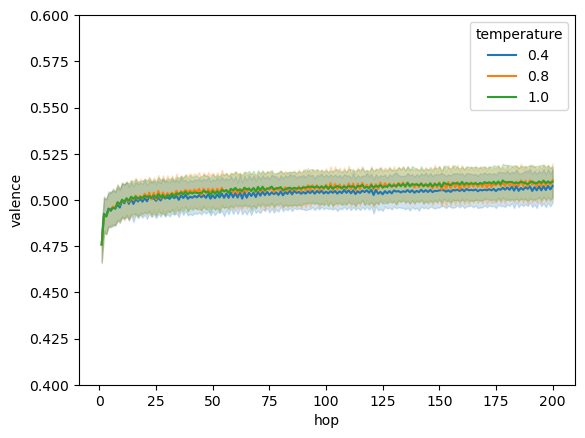

In [197]:
import seaborn as sns

m = "valence"
sns.lineplot(data=df_cum.loc[df_cum["metric"] == m], x="hop", y="value", hue="temperature", palette="tab10")
plt.ylabel(m)
plt.ylim(0.4, 0.6)

high top-p seems to show more upwards drift. And it does not seem to plateau.

(0.4, 0.6)

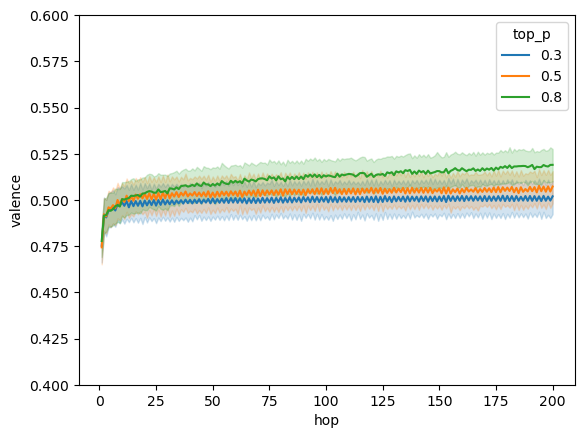

In [198]:
sns.lineplot(data=df_cum.loc[df_cum["metric"] == m], x="hop", y="value", hue="top_p", palette="tab10")
plt.ylabel(m)
plt.ylim(0.4, 0.6)

let's take a closer look

TODO: first, we need to fill the NaNs so we can look at the individual categories

In [199]:
df_cum

,model,config,msg_id,chain,hop,kind,metric,value,ver,created_at,temperature,top_p,length,domain,syntax,entities,polarity,tense,length_tk,seed_short
0,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,delta_len,-3.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
1,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,ratio_len,0.933333,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
2,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,jaccard,0.345455,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
3,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,entity_f1,1.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
4,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,triple_f1,0.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11339995,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,196,NaN,intensity,0.423425,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339996,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,197,NaN,intensity,0.462781,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339997,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,198,NaN,intensity,0.374153,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339998,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,199,NaN,intensity,0.486371,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
sns.lineplot(data=df_cum.loc[df_cum["metric"] == m], x="hop", y="value", hue="top_p", palette="tab10")
plt.ylabel(m)
plt.ylim(0.4, 0.6)

(0.0, 1.0)

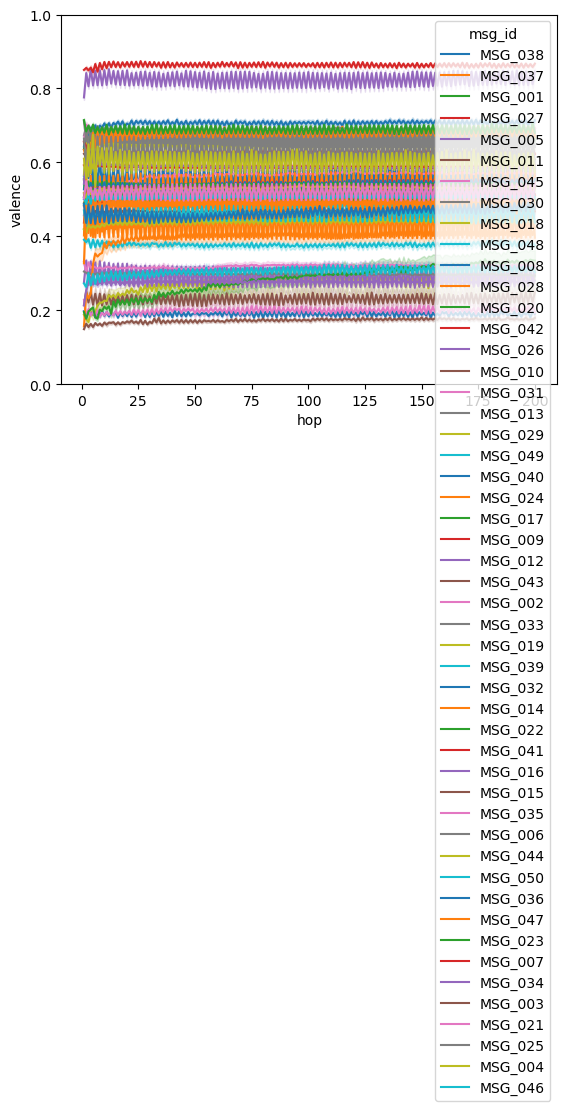

In [32]:
m = "valence"
sns.lineplot(data=df_cum.loc[df_cum["metric"] == m], x="hop", y="value", hue="msg_id", palette="tab10")
plt.ylabel(m)
plt.ylim(0, 1)

(0.0, 1.0)

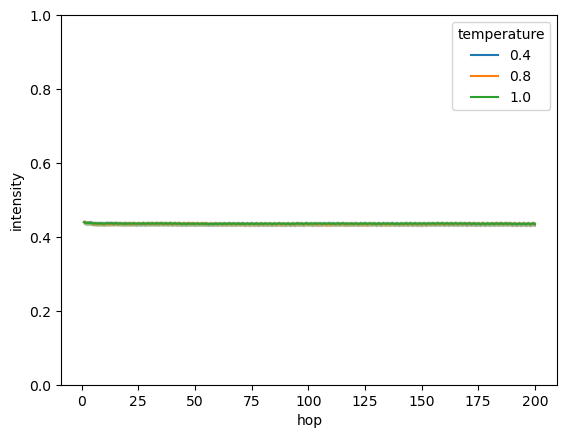

In [31]:
m = "intensity"
sns.lineplot(data=df_cum.loc[df_cum["metric"] == m], x="hop", y="value", hue="temperature", palette="tab10")
plt.ylabel(m)
plt.ylim(0, 1)

Seeds

In [49]:
seed_embeddings = EMBEDDING_MODEL.encode(
    seed_sentences["sentences"], 
    batch_size=64, 
    convert_to_numpy=True, 
    num_workers=0, 
    show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [50]:
def project(item_vecs, start_vec, end_vec):
    line_vec = end_vec - start_vec
    diff = item_vecs - start_vec
    
    return np.dot(diff, line_vec) / np.dot(line_vec, line_vec)

seed_valence = project(seed_embeddings, C_NEG, C_POS)
seed_intensity = project(seed_embeddings, C_NEUTRAL, C_INTENSE)

Last hop

In [33]:
# Get the new metric rows
new_metrics_df = process_and_melt(last_cum, data)

# Concatenate with the original dataframe
last_cum = pd.concat([last_cum, new_metrics_df], ignore_index=True, sort=False)

Batches:   0%|          | 0/64 [00:00<?, ?it/s]

In [43]:
df_cum

,model,config,msg_id,chain,hop,kind,metric,value,ver,created_at,temperature,top_p,length,domain,syntax,entities,polarity,tense,length_tk,seed_short
0,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,delta_len,-3.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
1,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,ratio_len,0.933333,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
2,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,jaccard,0.345455,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
3,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,entity_f1,1.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
4,gpt-4.1-nano,temp0.4_topp0.3,MSG_038,3,1,cumulative,triple_f1,0.000000,v1.0.0,2025-10-29T13:35:55.722848,0.4,0.3,long,fiction,passive,common-nouns,affirmative,present,45,In the quiet village wher...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11339995,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,196,NaN,intensity,0.423425,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339996,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,197,NaN,intensity,0.462781,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339997,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,198,NaN,intensity,0.374153,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11339998,gpt-4.1-nano,temp0.8_topp0.8,MSG_046,5,199,NaN,intensity,0.486371,NaN,NaN,0.8,0.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


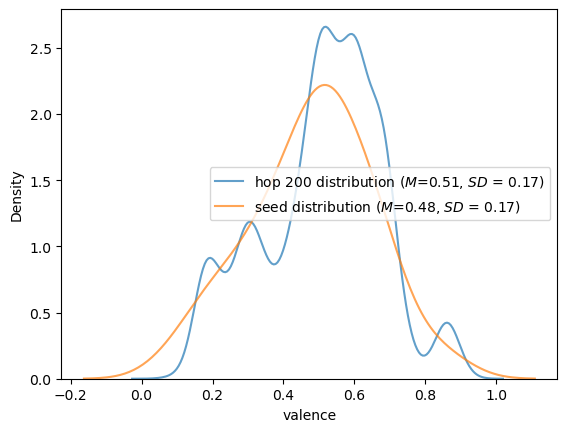

In [72]:
m = "valence"

sns.kdeplot(last_cum.loc[last_cum["metric"] == m, "value"],    alpha=0.7,
                 label=f"hop 200 distribution ($M$={last_cum.loc[last_cum["metric"] == m, "value"].mean():.2f}, $SD$ = {last_cum.loc[last_cum["metric"] == m, "value"].std():.2f})",
)

sns.kdeplot(seed_valence,    alpha=0.7,
                 label=f"seed distribution ($M$={seed_valence.mean():.2f}, $SD$ = {seed_valence.std():.2f})",
)

plt.xlabel(m)
plt.legend()
# plt.ylim(0, 400)

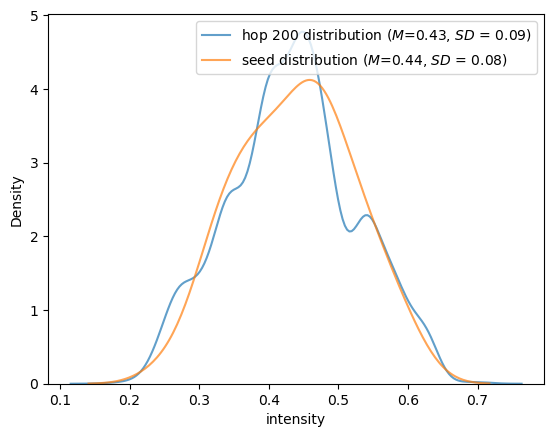

In [86]:
m = "intensity"

sns.kdeplot(last_cum.loc[last_cum["metric"] == m, "value"],    alpha=0.7,
                 label=f"hop 200 distribution ($M$={last_cum.loc[last_cum["metric"] == m, "value"].mean():.2f}, $SD$ = {last_cum.loc[last_cum["metric"] == m, "value"].std():.2f})",
)

sns.kdeplot(seed_intensity,    alpha=0.7,
                 label=f"seed distribution ($M$={seed_intensity.mean():.2f}, $SD$ = {seed_intensity.std():.2f})",
)

plt.xlabel(m)
plt.legend()
# plt.ylim(0, 400)

In [ ]:
df_extra = pd.DataFrame({"seed_valence":seed_valence, "seed_intensity": seed_intensity}).reset_index().rename(columns={"index":"msg_id"})
df_extra["msg_id"] += 1
df_extra["msg_id"] = "MSG_" + df_extra["msg_id"].astype(str).str.zfill(3)

last_cum = last_cum.merge(df_extra, on="msg_id", validate="m:1")

Differences

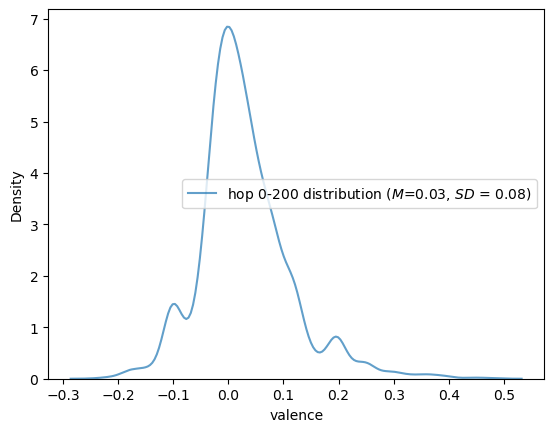

In [108]:
m = "valence"
diff = last_cum.loc[last_cum["metric"] == m, "value"] - last_cum.loc[last_cum["metric"] == m, f"seed_{m}"]
sns.kdeplot(diff,    alpha=0.7,
                 label=f"hop 0-200 distribution ($M$={diff.mean():.2f}, $SD$ = {diff.std():.2f})",
)


plt.xlabel(m)
plt.legend()
# plt.ylim(0, 400)

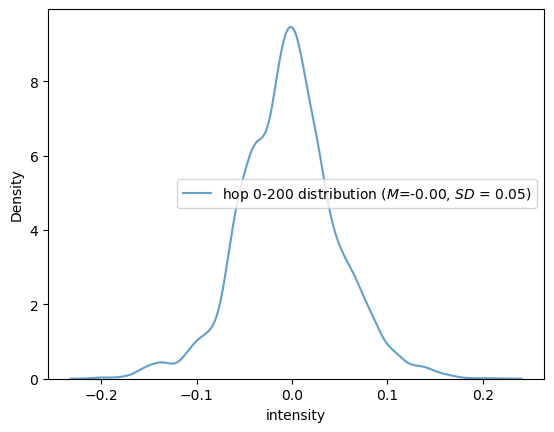

In [107]:
m = "intensity"
diff = last_cum.loc[last_cum["metric"] == m, "value"] - last_cum.loc[last_cum["metric"] == m, f"seed_{m}"]
sns.kdeplot(diff,    alpha=0.7,
                 label=f"hop 0-200 distribution ($M$={diff.mean():.2f}, $SD$ = {diff.std():.2f})",
)


plt.xlabel(m)
plt.legend()
# plt.ylim(0, 400)

/tmp/ipykernel_60584/230892989.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


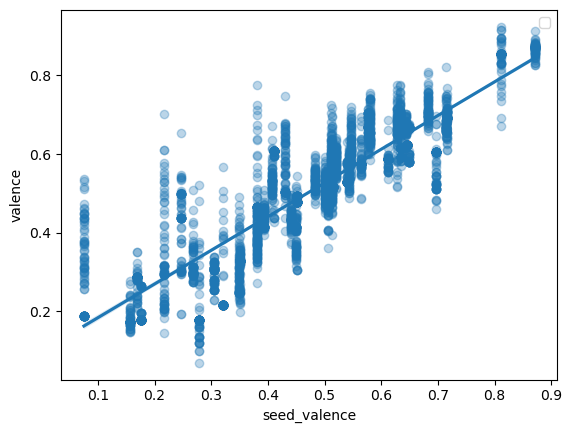

In [180]:
m = "valence"
df_view = last_cum.loc[last_cum["metric"] == m].copy()
df_view["diff"] = df_view["value"] - df_view[f"seed_{m}"]

sns.regplot(data=df_view, x=f"seed_{m}", y="value", scatter_kws=dict(alpha=0.3))


plt.ylabel(m)
plt.legend()
# plt.ylim(0, 400)

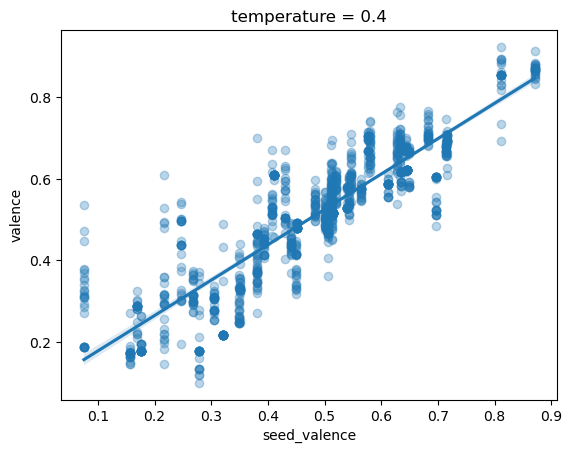

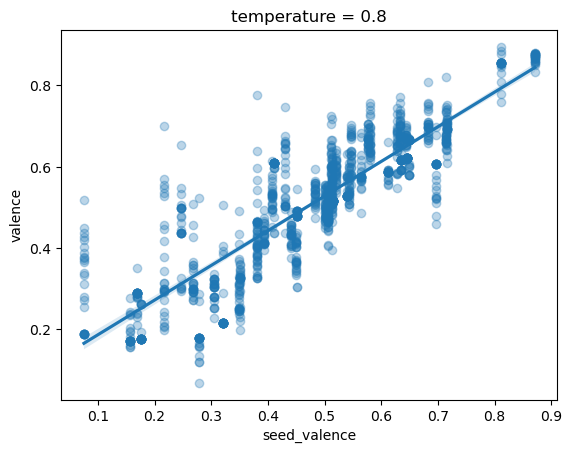

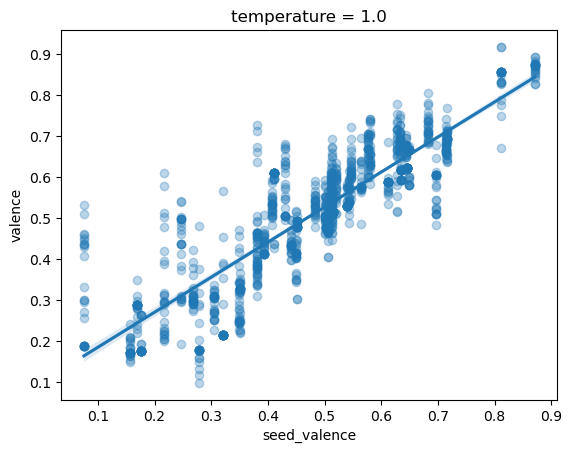

In [181]:
for temp in df_view["temperature"].unique():
    sns.regplot(data=df_view.loc[df_view["temperature"] == temp], x=f"seed_{m}", y="value",scatter_kws=dict(alpha=0.3))
    plt.title(f"temperature = {temp}")
    plt.ylabel(m)
    plt.show()

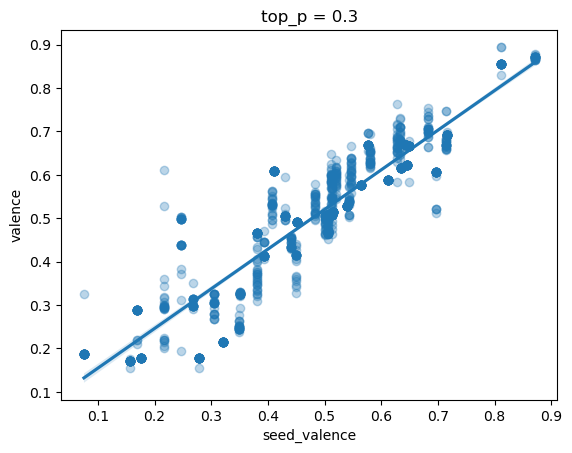

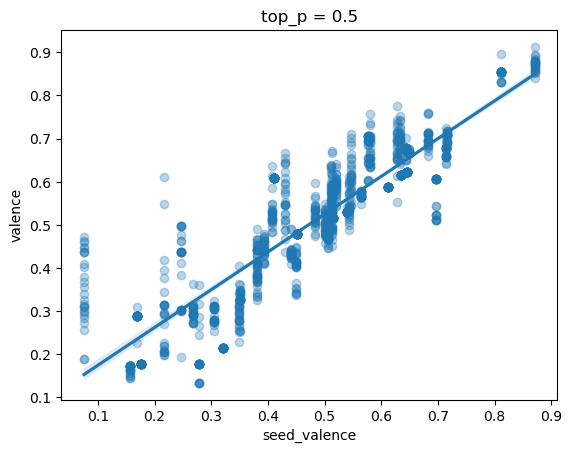

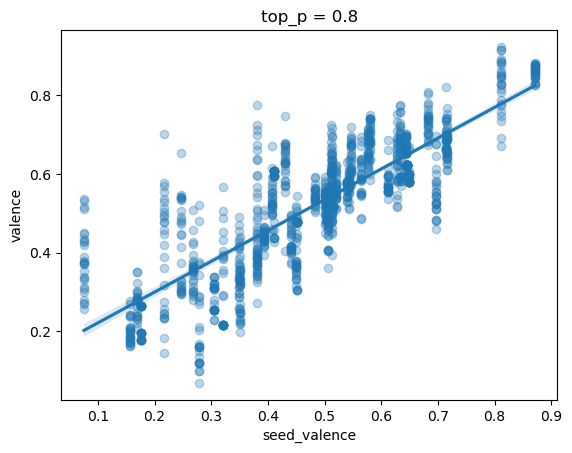

In [182]:
for t in df_view["top_p"].unique():
    sns.regplot(data=df_view.loc[df_view["top_p"] == t], x=f"seed_{m}", y="value",scatter_kws=dict(alpha=0.3))
    plt.title(f"top_p = {t}")
    plt.ylabel(m)
    plt.show()

How much does valence shift depending on the initial valance value? It appears that sentences with more negative initial valence are slightly shifted towards positive valence.

This seem to be especially true for higher top-p values.

/tmp/ipykernel_60584/1611794245.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


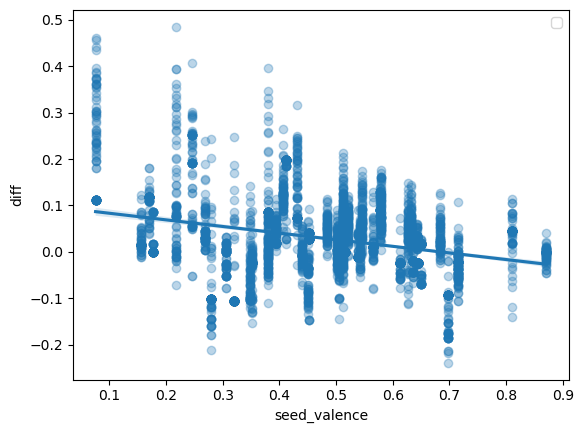

In [188]:
sns.regplot(data=df_view, x=f"seed_{m}", y="diff", scatter_kws=dict(alpha=0.3))


plt.legend()
# plt.ylim(0, 400)

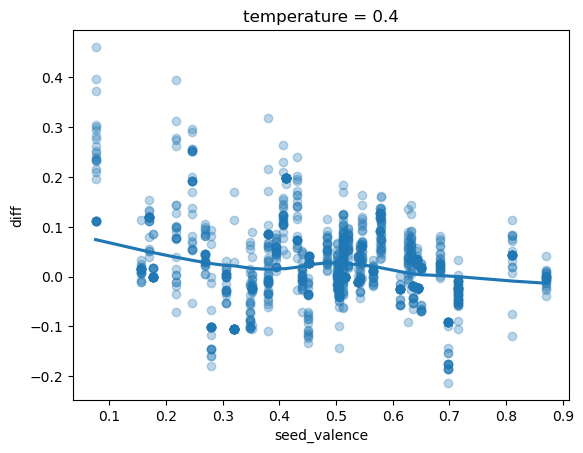

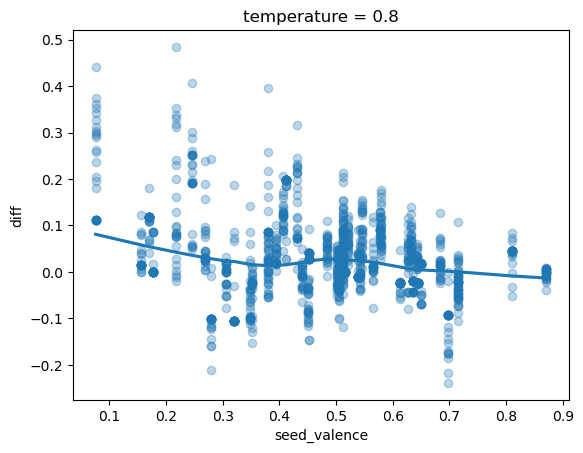

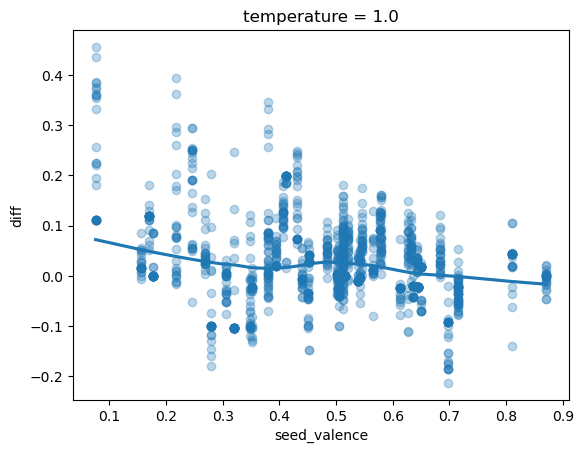

In [189]:
for temp in df_view["temperature"].unique():
    sns.regplot(data=df_view.loc[df_view["temperature"] == temp], x=f"seed_{m}", y="diff",scatter_kws=dict(alpha=0.3), lowess=True)
    
    plt.title(f"temperature = {temp}")
    plt.show()

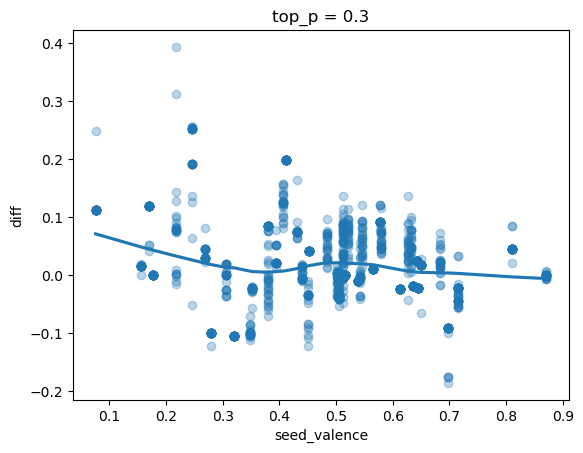

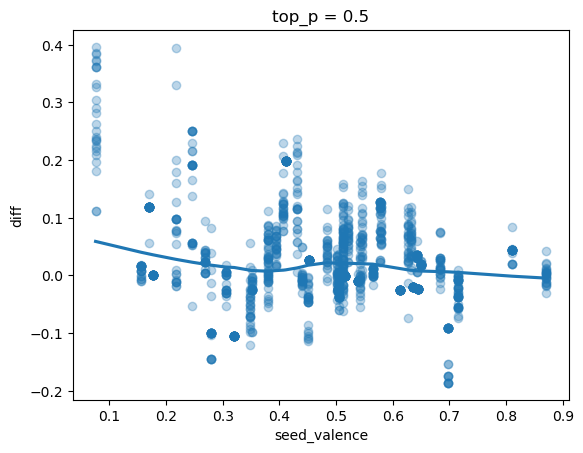

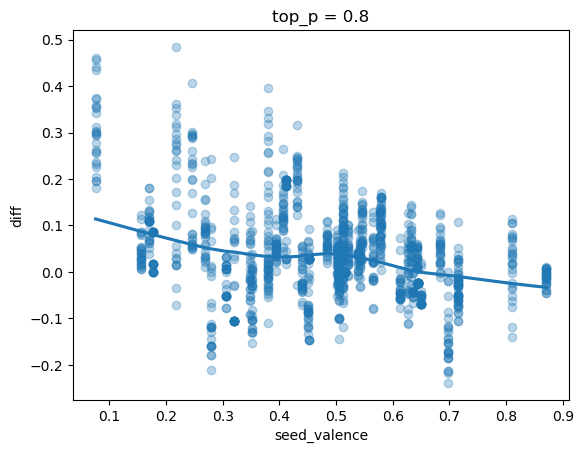

In [186]:
for t in df_view["top_p"].unique():
    sns.regplot(data=df_view.loc[df_view["top_p"] == t], x=f"seed_{m}", y="diff",scatter_kws=dict(alpha=0.3), lowess=True)
    
    plt.title(f"top_p = {t}")
    plt.show()

/tmp/ipykernel_60584/4076519716.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


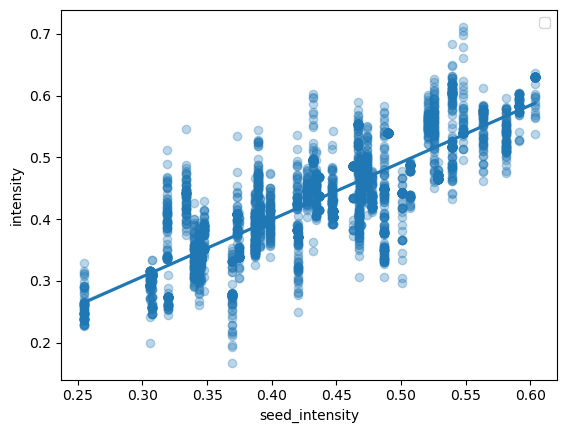

In [190]:
m = "intensity"
df_view = last_cum.loc[last_cum["metric"] == m].copy()
df_view["diff"] = df_view["value"] - df_view[f"seed_{m}"]

sns.regplot(data=df_view, x=f"seed_{m}", y="value", scatter_kws=dict(alpha=0.3))


plt.ylabel(m)
plt.legend()
# plt.ylim(0, 400)

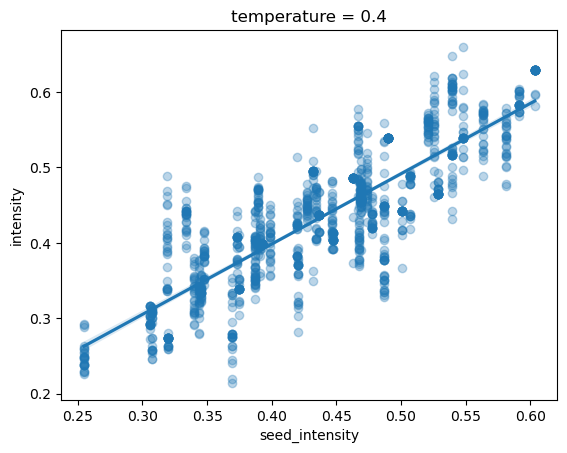

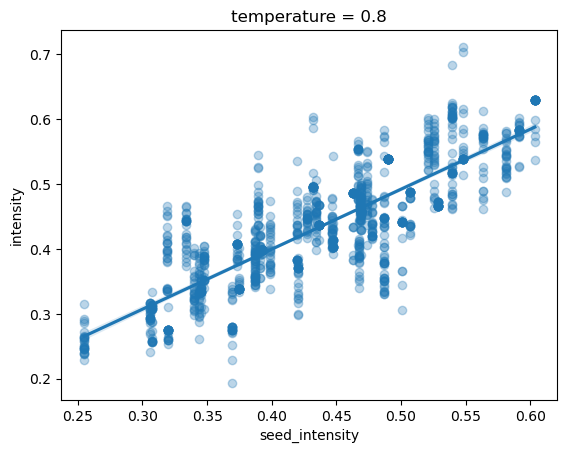

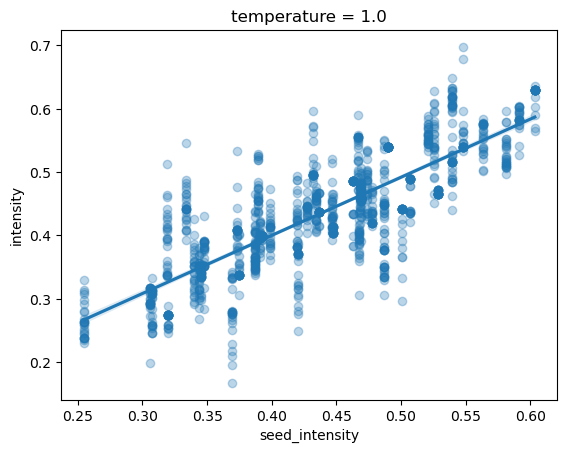

In [191]:
for temp in df_view["temperature"].unique():
    sns.regplot(data=df_view.loc[df_view["temperature"] == temp], x=f"seed_{m}", y="value",scatter_kws=dict(alpha=0.3))
    plt.title(f"temperature = {temp}")
    plt.ylabel(m)
    plt.show()

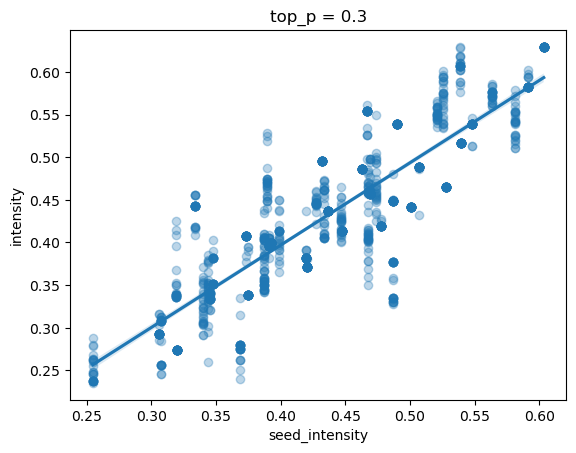

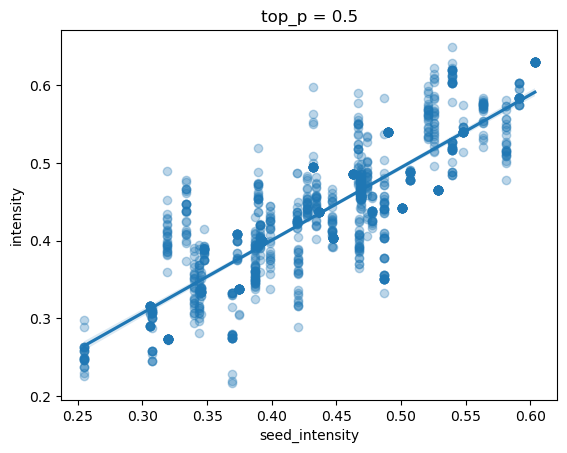

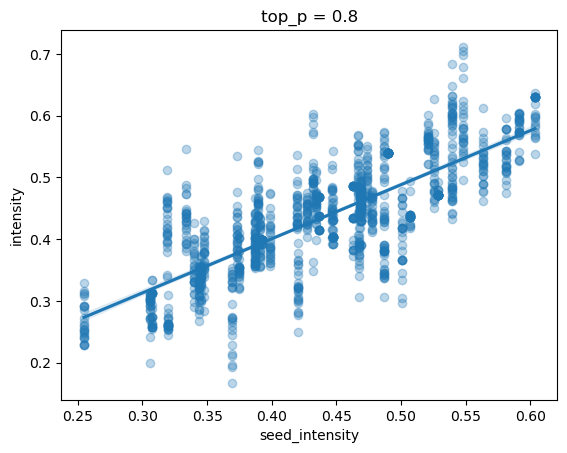

In [192]:
for t in df_view["top_p"].unique():
    sns.regplot(data=df_view.loc[df_view["top_p"] == t], x=f"seed_{m}", y="value",scatter_kws=dict(alpha=0.3))
    plt.title(f"top_p = {t}")
    plt.ylabel(m)
    plt.show()

How much does intensity shift depending on the initial valance value? There does not appear to be a strong trend. Slight intensity upwards correction for low intensity seeds.

/tmp/ipykernel_60584/3175216713.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


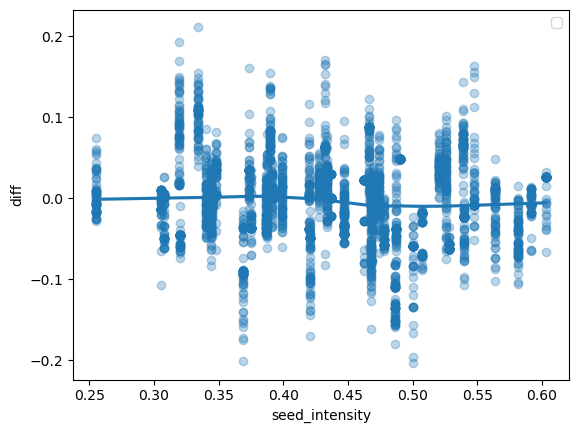

In [193]:
sns.regplot(data=df_view, x=f"seed_{m}", y="diff", scatter_kws=dict(alpha=0.3), lowess=True)


plt.legend()
# plt.ylim(0, 400)

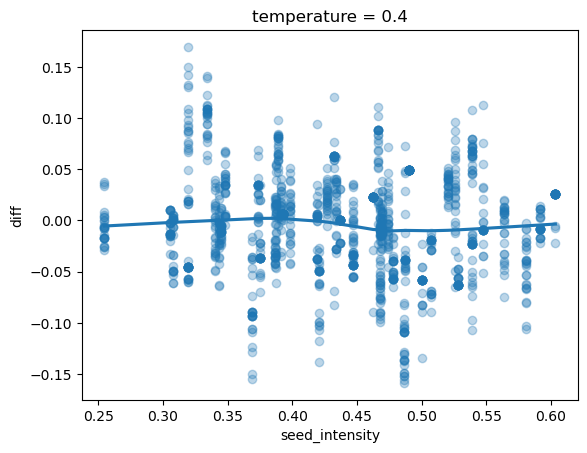

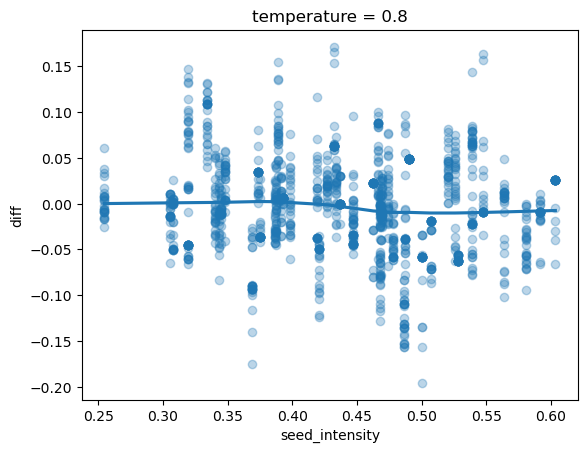

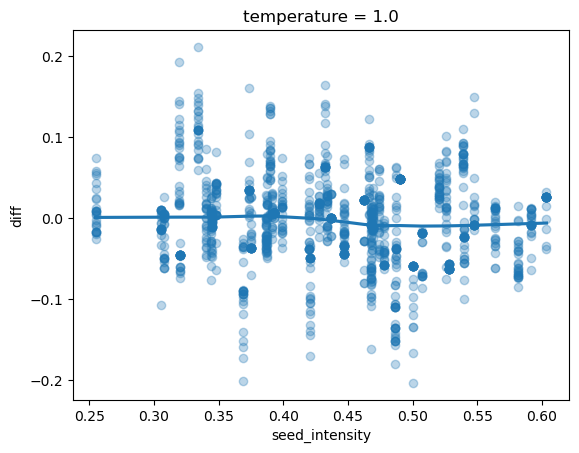

In [194]:
for temp in df_view["temperature"].unique():
    sns.regplot(data=df_view.loc[df_view["temperature"] == temp], x=f"seed_{m}", y="diff",scatter_kws=dict(alpha=0.3), lowess=True)
    
    plt.title(f"temperature = {temp}")
    plt.show()

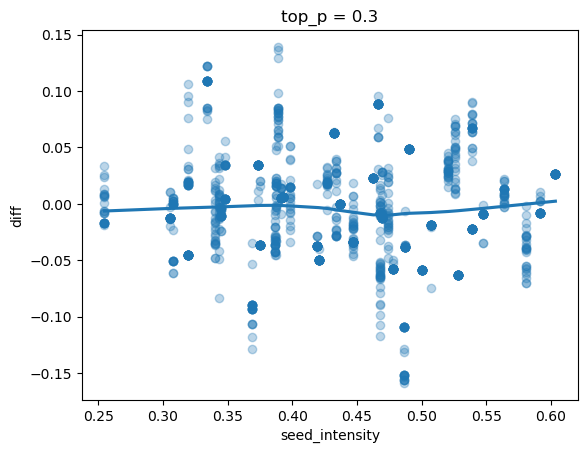

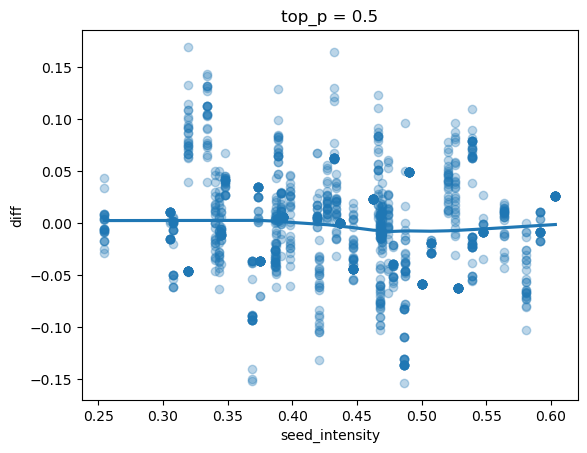

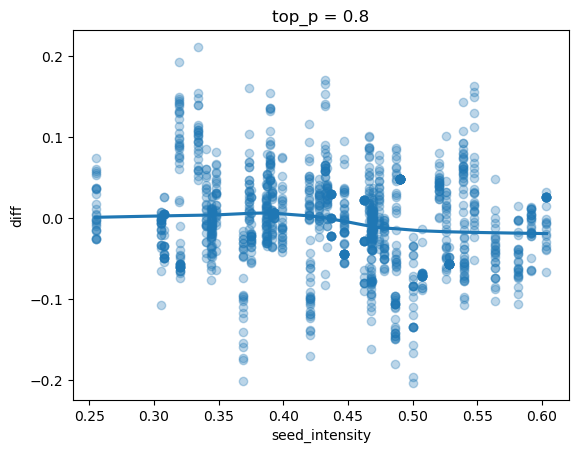

In [195]:
for t in df_view["top_p"].unique():
    sns.regplot(data=df_view.loc[df_view["top_p"] == t], x=f"seed_{m}", y="diff",scatter_kws=dict(alpha=0.3), lowess=True)
    
    plt.title(f"top_p = {t}")
    plt.show()